In [157]:
import pandas as pd
import os
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [158]:
data_set_1 = pd.read_csv('/Users/natalialogvinova/Desktop/DS diploma/DS-17 diploma/Raw_Jobs.csv', sep = ';')
print(data_set_1.shape)

(561989, 12)


In [159]:
data_set_1['key_skills'].values

array([nan, nan, nan, ...,
       'Желание работать и зарабатывать,Быстрообучаемый,Физическая выносливость',
       nan, nan], dtype=object)

In [160]:
def split_salary_column(df, salary_column, new_columns_prefix=''):
    """
    Разделяет столбец с зарплатой на три отдельных столбца.
    
    Parameters:
    df (DataFrame): Исходный датафрейм
    salary_column (str): Название столбца с зарплатой
    new_columns_prefix (str): Префикс для новых столбцов
    
    Returns:
    DataFrame: Дадафрейм с добавленными столбцами salary_from, salary_to, currency
    """
    
    # Создаем копию датафрейма
    result_df = data_set_1.copy()
    
    # Создаем новые столбцы
    result_df[f'{new_columns_prefix}salary_from'] = np.nan
    result_df[f'{new_columns_prefix}salary_to'] = np.nan
    result_df[f'{new_columns_prefix}currency'] = np.nan
    
    # Регулярные выражения для парсинга
    salary_pattern = r'от\s*(\d+[\d\s]*)\s*до\s*(\d+[\d\s]*)\s*([A-Z]{3})?|до\s*(\d+[\d\s]*)\s*([A-Z]{3})?|от\s*(\d+[\d\s]*)\s*([A-Z]{3})?|(\d+[\d\s]*)\s*([A-Z]{3})?'
    not_specified_pattern = r'з/п не указана'
    currency_pattern = r'([A-Z]{3})$'
    
    for idx, value in enumerate(result_df[salary_column]):
        if pd.isna(value):
            continue
            
        value_str = str(value).strip()
        
        # Проверяем на "з/п не указана"
        if re.search(not_specified_pattern, value_str, re.IGNORECASE):
            result_df.at[idx, f'{new_columns_prefix}salary_from'] = np.nan
            result_df.at[idx, f'{new_columns_prefix}salary_to'] = np.nan
            result_df.at[idx, f'{new_columns_prefix}currency'] = np.nan
            continue
        
        # Ищем валюту в конце строки
        currency_match = re.search(currency_pattern, value_str)
        currency = currency_match.group(1) if currency_match else np.nan
        
        # Парсим зарплату
        salary_match = re.search(salary_pattern, value_str, re.IGNORECASE)
        
        if salary_match:
            groups = salary_match.groups()
            
            # Вариант: "от X до Y CUR"
            if groups[0] and groups[1]:
                salary_from = groups[0].replace(' ', '')
                salary_to = groups[1].replace(' ', '')
                currency_val = groups[2] if groups[2] else currency
            
            # Вариант: "до X CUR"
            elif groups[3]:
                salary_from = np.nan
                salary_to = groups[3].replace(' ', '')
                currency_val = groups[4] if groups[4] else currency
            
            # Вариант: "от X CUR"
            elif groups[5]:
                salary_from = groups[5].replace(' ', '')
                salary_to = np.nan
                currency_val = groups[6] if groups[6] else currency
            
            # Вариант: "X CUR"
            elif groups[7]:
                salary_from = groups[7].replace(' ', '')
                salary_to = np.nan
                currency_val = groups[8] if groups[8] else currency
            
            else:
                salary_from = np.nan
                salary_to = np.nan
                currency_val = np.nan
            
            # Записываем значения
            result_df.at[idx, f'{new_columns_prefix}salary_from'] = float(salary_from) if salary_from and salary_from != 'nan' else np.nan
            result_df.at[idx, f'{new_columns_prefix}salary_to'] = float(salary_to) if salary_to and salary_to != 'nan' else np.nan
            result_df.at[idx, f'{new_columns_prefix}currency'] = currency_val if currency_val and currency_val != 'nan' else np.nan
    
    return result_df

In [161]:
data_set_1 = split_salary_column(data_set_1, 'salary')

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_88488/689102006.py:82: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'RUR' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result_df.at[idx, f'{new_columns_prefix}currency'] = currency_val if currency_val and currency_val != 'nan' else np.nan


In [162]:
def split_experience_column(df, experience_column, new_columns_prefix=''):
    """
    Разделяет столбец с опытом работы на три отдельных столбца.
    
    Parameters:
    df (DataFrame): Исходный датафрейм
    experience_column (str): Название столбца с опытом работы
    new_columns_prefix (str): Префикс для новых столбцов
    
    Returns:
    DataFrame: Дадафрейм с добавленными столбцами experience_from, experience_to, no_experience
    """
    
    # Создаем копию датафрейма
    result_df = df.copy()
    
    # Создаем новые столбцы
    result_df[f'{new_columns_prefix}experience_from'] = np.nan
    result_df[f'{new_columns_prefix}experience_to'] = np.nan
    result_df[f'{new_columns_prefix}no_experience'] = False
    
    # Регулярные выражения для парсинга
    no_experience_pattern = r'(нет опыта|без опыта|без опыта работы|опыт не требуется|не требуется опыт)'
    
    experience_pattern = r'''
        от\s+(\d+)\s*(?:года|лет|год)\s+до\s+(\d+)\s*(?:года|лет|год)|  # от X года до Y года
        до\s+(\d+)\s*(?:года|лет|год)|                                  # до X года
        от\s+(\d+)\s*(?:года|лет|год)|                                  # от X года
        более\s+(\d+)\s*(?:года|лет|год)|                               # более X года
        (\d+)\s*(?:года|лет|год)                                        # X года
    '''
    
    for idx, value in enumerate(result_df[experience_column]):
        if pd.isna(value):
            continue
            
        value_str = str(value).strip().lower()
        
        # Проверяем на "нет опыта"
        if re.search(no_experience_pattern, value_str, re.IGNORECASE):
            result_df.at[idx, f'{new_columns_prefix}no_experience'] = True
            result_df.at[idx, f'{new_columns_prefix}experience_from'] = np.nan
            result_df.at[idx, f'{new_columns_prefix}experience_to'] = np.nan
            continue
        
        # Парсим опыт работы
        experience_match = re.search(experience_pattern, value_str, re.IGNORECASE | re.VERBOSE)
        
        if experience_match:
            groups = experience_match.groups()
            
            # Вариант: "от X года до Y года"
            if groups[0] and groups[1]:
                experience_from = groups[0]
                experience_to = groups[1]
            
            # Вариант: "до X года"
            elif groups[2]:
                experience_from = np.nan
                experience_to = groups[2]
            
            # Вариант: "от X года"
            elif groups[3]:
                experience_from = groups[3]
                experience_to = np.nan
            
            # Вариант: "более X года"
            elif groups[4]:
                experience_from = groups[4]
                experience_to = np.nan
            
            # Вариант: "X года"
            elif groups[5]:
                experience_from = groups[5]
                experience_to = np.nan
            
            else:
                experience_from = np.nan
                experience_to = np.nan
            
            # Записываем значения
            result_df.at[idx, f'{new_columns_prefix}experience_from'] = float(experience_from) if experience_from and experience_from != 'nan' else np.nan
            result_df.at[idx, f'{new_columns_prefix}experience_to'] = float(experience_to) if experience_to and experience_to != 'nan' else np.nan
            
            # Устанавливаем no_experience = False если есть хотя бы одно значение
            if pd.notna(result_df.at[idx, f'{new_columns_prefix}experience_from']) or \
               pd.notna(result_df.at[idx, f'{new_columns_prefix}experience_to']):
                result_df.at[idx, f'{new_columns_prefix}no_experience'] = False
    
    return result_df

# Дополнительная функция для проверки результатов
def check_experience_splitting(df, original_column):
    """Проверяет корректность разделения опыта работы"""
    print("=== ПРОВЕРКА РАЗДЕЛЕНИЯ ОПЫТА РАБОТЫ ===")
    print(f"Всего строк: {len(df)}")
    print(f"Без опыта: {df['no_experience'].sum()}")
    print(f"С опытом: {len(df) - df['no_experience'].sum()}")
    
    print("\nПримеры данных:")
    for i in range(min(10, len(df))):
        print(f"{i}: '{df[original_column].iloc[i]}' -> "
              f"from: {df['experience_from'].iloc[i]}, "
              f"to: {df['experience_to'].iloc[i]}, "
              f"no_exp: {df['no_experience'].iloc[i]}")

In [163]:
data_set_1 = split_experience_column(data_set_1, 'experience')

In [164]:
def split_by_comma_advanced(result_df, source_column, concrete_column='job_type_concrete', schedule_column='schedule', to_lowercase=True, remove_extra_spaces=True):
    """
    Расширенная версия с опциями предобработки.
    
    Parameters:
    to_lowercase (bool): Приводить ли к нижнему регистру
    remove_extra_spaces (bool): Убирать ли лишние пробелы
    """
    
    result_df[concrete_column] = np.nan
    result_df[schedule_column] = np.nan
    
    for idx, value in enumerate(result_df[source_column]):
        if pd.isna(value):
            continue
            
        value_str = str(value).strip()
        
        # Приведение к нижнему регистру (если включено)
        if to_lowercase:
            value_str = value_str.lower()
        
        # Удаление лишних пробелов (если включено)
        if remove_extra_spaces:
            value_str = ' '.join(value_str.split())
        
        if ',' in value_str:
            parts = value_str.split(',', 1)
            concrete_part = parts[0].strip()
            schedule_part = parts[1].strip()
            
            result_df.at[idx, concrete_column] = concrete_part if concrete_part else np.nan
            result_df.at[idx, schedule_column] = schedule_part if schedule_part else np.nan
        else:
            result_df.at[idx, concrete_column] = value_str if value_str else np.nan
            result_df.at[idx, schedule_column] = np.nan
    
    return result_df

In [165]:
data_set_1 = split_by_comma_advanced(data_set_1, 'job_type')

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_88488/4133146593.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'полная занятость' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result_df.at[idx, concrete_column] = concrete_part if concrete_part else np.nan
/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_88488/4133146593.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'полный день' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result_df.at[idx, schedule_column] = schedule_part if schedule_part else np.nan


In [166]:
columns_to_drop = ['salary', 'experience', 'job_type']
data_set_1 = data_set_1.drop(columns=columns_to_drop)

In [167]:
data_set_1

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,salary_to,currency,experience_from,experience_to,no_experience,job_type_concrete,schedule
0,1,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,160000.0,RUR,6.0,NaN,False,полная занятость,полный день
1,2,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,NaN,NaN,1.0,3.0,False,полная занятость,полный день
2,3,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,NaN,NaN,1.0,3.0,False,полная занятость,полный день
3,4,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,NaN,NaN,6.0,NaN,False,полная занятость,полный день
4,5,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,NaN,NaN,NaN,NaN,True,стажировка,полный день
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
561984,561995,81056636,Аналитик (бизнес/системный),Мы – аккредитованная IT-компания «Формат код...,NaN,Формат кода,NaN,06.06.2023,open,NaN,NaN,NaN,1.0,3.0,False,полная занятость,полный день
561985,561996,81036428,Разнорабочий/транспортировщик,Обязанности: Работа транспортировщико...,NaN,Консалтинг Групп,NaN,09.06.2023,open,110000.0,130000.0,RUR,NaN,NaN,True,полная занятость,вахтовый метод
561986,561997,81962116,Рабочий на производство,На крупные федеральные производства РФ для р...,"Желание работать и зарабатывать,Быстрообучаемы...",ПРОКАДРЫ,NaN,15.06.2023,open,80000.0,85000.0,RUR,NaN,NaN,True,полная занятость,вахтовый метод
561987,561998,81487376,Менеджер по туризму,"В связи с открытием нового офиса в г. Мытищи, ...",NaN,Скайлайн,NaN,03.06.2023,open,60000.0,NaN,RUR,1.0,3.0,False,полная занятость,сменный график


In [168]:
data_set_2 = pd.read_csv('/Users/natalialogvinova/Desktop/DS diploma/DS-17 diploma/Data Analyst Vacancies.csv', sep = ',')
print(data_set_2.shape)
data_set_2.head(5)

(1000, 36)


,id,premium,name,department,has_test,response_letter_required,area,salary,type,address,...,working_time_intervals,working_time_modes,accept_temporary,professional_roles,accept_incomplete_resumes,experience,employment,adv_response_url,is_adv_vacancy,branding
0,86571284,False,"Data Scientist (стажер), удаленно",NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'from': None, 'to': 15000, 'currency': 'RUR',...","{'id': 'open', 'name': 'Открытая'}",NaN,...,"[{'id': 'from_four_to_six_hours_in_a_day', 'na...","[{'id': 'start_after_sixteen', 'name': 'Можно ...",False,"[{'id': '96', 'name': 'Программист, разработчи...",False,"{'id': 'noExperience', 'name': 'Нет опыта'}","{'id': 'probation', 'name': 'Стажировка'}",NaN,False,NaN
1,87273897,False,Data Analyst,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,"{'id': 'open', 'name': 'Открытая'}",NaN,...,[],[],False,"[{'id': '156', 'name': 'BI-аналитик, аналитик ...",False,"{'id': 'between3And6', 'name': 'От 3 до 6 лет'}","{'id': 'full', 'name': 'Полная занятость'}",NaN,False,NaN
2,87271975,False,Political analyst,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,"{'id': 'anonymous', 'name': 'Анонимная'}",NaN,...,[],[],False,"[{'id': '40', 'name': 'Другое'}]",False,"{'id': 'moreThan6', 'name': 'Более 6 лет'}","{'id': 'full', 'name': 'Полная занятость'}",NaN,False,NaN
3,86195321,False,Junior Data Scientist,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,"{'id': 'open', 'name': 'Открытая'}",NaN,...,[],[],False,"[{'id': '165', 'name': 'Дата-сайентист'}]",False,"{'id': 'between1And3', 'name': 'От 1 года до 3...","{'id': 'full', 'name': 'Полная занятость'}",NaN,False,"{'type': 'MAKEUP', 'tariff': None}"
4,87265216,False,Юрист,NaN,True,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,"{'id': 'open', 'name': 'Открытая'}",NaN,...,[],[],False,"[{'id': '146', 'name': 'Юрист'}]",False,"{'id': 'between1And3', 'name': 'От 1 года до 3...","{'id': 'full', 'name': 'Полная занятость'}",NaN,False,NaN


In [169]:
import ast

def split_salary_column_dict_string(df, salary_column):
    """
    Разделяет столбец с зарплатой в формате строки-словаря на три отдельных столбца.
    
    Parameters:
    df (DataFrame): Исходный датафрейм
    salary_column (str): Название столбца с зарплатой в формате строки-словаря
    
    Returns:
    DataFrame: Дадафрейм с добавленными столбцами salary_from, salary_to, currency
    """
    
    # Создаем копию датафрейма
    result_df = df.copy()
    
    # Создаем новые столбцы
    result_df['salary_from'] = np.nan
    result_df['salary_to'] = np.nan
    result_df['currency'] = np.nan
    
    for idx, value in enumerate(result_df[salary_column]):
        # Пропускаем NaN значения
        if pd.isna(value):
            continue
            
        # Пропускаем пустые строки
        if isinstance(value, str) and value.strip() == '':
            continue
            
        # Пробуем распарсить строку как словарь Python
        try:
            # Используем ast.literal_eval для безопасного парсинга
            salary_dict = ast.literal_eval(value)
            
            # Проверяем, что получили словарь
            if isinstance(salary_dict, dict):
                # Извлекаем значения, преобразуя None в NaN
                salary_from = salary_dict.get('from')
                salary_to = salary_dict.get('to')
                currency = salary_dict.get('currency')
                
                # Записываем значения
                result_df.at[idx, 'salary_from'] = float(salary_from) if salary_from is not None else np.nan
                result_df.at[idx, 'salary_to'] = float(salary_to) if salary_to is not None else np.nan
                result_df.at[idx, 'currency'] = currency if currency is not None else np.nan
                
        except (ValueError, SyntaxError, TypeError) as e:
            # Если не удалось распарсить, оставляем NaN
            print(f"Ошибка парсинга строки {idx}: '{value}' - {e}")
            continue
    
    return result_df

In [170]:
data_set_2 = split_salary_column_dict_string(data_set_2, 'salary')

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_88488/477433147.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'RUR' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result_df.at[idx, 'currency'] = currency if currency is not None else np.nan


In [171]:
def split_experience_column_simple(df, experience_column):
    """
    Упрощенная версия, которая извлекает только поле name и парсит его.
    """
    
    result_df = df.copy()
    result_df['experience_from'] = np.nan
    result_df['experience_to'] = np.nan
    result_df['no_experience'] = False
    
    for idx, value in enumerate(result_df[experience_column]):
        if pd.isna(value):
            continue
            
        value_str = str(value).strip()
        if not value_str or value_str == 'nan':
            continue
            
        # Извлекаем текст из поля name
        name_text = None
        
        # Пробуем извлечь поле name разными способами
        try:
            # Способ 1: через ast.literal_eval
            exp_dict = ast.literal_eval(value_str)
            if isinstance(exp_dict, dict) and 'name' in exp_dict:
                name_text = str(exp_dict['name']).strip().lower()
        except:
            # Способ 2: через поиск в строке
            name_match = re.search(r"'name'\s*:\s*'([^']*)'", value_str)
            if name_match:
                name_text = name_match.group(1).strip().lower()
        
        if not name_text:
            continue
        
        # Парсим текст опыта
        # 1. Проверяем "нет опыта"
        if any(phrase in name_text for phrase in ['нет опыта', 'без опыта', 'опыт не требуется']):
            result_df.at[idx, 'no_experience'] = True
            result_df.at[idx, 'experience_from'] = 0
            result_df.at[idx, 'experience_to'] = 0
            continue
        
        # 2. Парсим числовые значения
        # "от X до Y"
        range_match = re.search(r'от\s*(\d+)\s*до\s*(\d+)', name_text)
        if range_match:
            result_df.at[idx, 'experience_from'] = float(range_match.group(1))
            result_df.at[idx, 'experience_to'] = float(range_match.group(2))
            continue
        
        # "от X"
        from_match = re.search(r'от\s*(\d+)', name_text)
        if from_match:
            result_df.at[idx, 'experience_from'] = float(from_match.group(1))
            continue
        
        # "до X"
        to_match = re.search(r'до\s*(\d+)', name_text)
        if to_match:
            result_df.at[idx, 'experience_to'] = float(to_match.group(1))
            continue
        
        # "более X"
        more_match = re.search(r'более\s*(\d+)', name_text)
        if more_match:
            result_df.at[idx, 'experience_from'] = float(more_match.group(1))
            continue
        
        # "X лет/год/года"
        simple_match = re.search(r'(\d+)\s*(?:лет|год|года)', name_text)
        if simple_match:
            result_df.at[idx, 'experience_from'] = float(simple_match.group(1))
    
    return result_df

In [172]:
data_set_2 = split_experience_column_simple(data_set_2, 'experience')

In [173]:
def extract_job_type_simple(df, source_column, target_column):
    
    result_df = df.copy()
    result_df[target_column] = np.nan
    
    for idx, value in enumerate(result_df[source_column]):
        if pd.isna(value):
            continue
            
        value_str = str(value).strip()
        if not value_str or value_str == 'nan':
            continue
        
        # Пробуем извлечь поле name разными способами
        try:
            # Способ 1: через ast.literal_eval
            job_dict = ast.literal_eval(value_str)
            if isinstance(job_dict, dict) and 'name' in job_dict:
                result_df.at[idx, target_column] = str(job_dict['name']).strip()
        except:
            # Способ 2: через регулярное выражение (если не получается распарсить как словарь)
            try:
                import re
                name_match = re.search(r"'name'\s*:\s*'([^']*)'", value_str)
                if name_match:
                    result_df.at[idx, target_column] = name_match.group(1).strip()
            except:
                continue
    
    return result_df

In [174]:
data_set_2 = extract_job_type_simple(data_set_2, 'employment', 'job_type_concrete')

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_88488/1209430768.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Стажировка' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result_df.at[idx, target_column] = str(job_dict['name']).strip()


In [175]:
data_set_2['location'] = 'Москва'

In [176]:
data_set_2['type'] = 'open'

In [177]:
data_set_2 = extract_job_type_simple(data_set_2, 'department', 'company')

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_88488/1209430768.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ВкусВилл. Офис' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result_df.at[idx, target_column] = str(job_dict['name']).strip()


In [178]:
def quick_extract_company(df, source_column, target_column='company'):
    """
    Быстрая версия для извлечения названия компании.
    """
    
    def extract_company_value(value):
        if pd.isna(value):
            return np.nan
            
        try:
            value_str = str(value)
            if not value_str or value_str == 'nan':
                return np.nan
                
            # Пробуем распарсить как словарь
            if value_str.startswith('{'):
                company_dict = ast.literal_eval(value_str)
                if isinstance(company_dict, dict):
                    return company_dict.get('name', np.nan)
            return np.nan
        except:
            return np.nan
    
    result_df = df.copy()
    result_df[target_column] = result_df[source_column].apply(extract_company_value)
    
    return result_df

In [179]:
data_set_2 = quick_extract_company(data_set_2, 'employer')

In [180]:
data_set_2 

,id,premium,name,department,has_test,response_letter_required,area,salary,type,address,...,branding,salary_from,salary_to,currency,experience_from,experience_to,no_experience,job_type_concrete,location,company
0,86571284,False,"Data Scientist (стажер), удаленно",NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'from': None, 'to': 15000, 'currency': 'RUR',...",open,NaN,...,NaN,NaN,15000.0,RUR,0.0,0.0,True,Стажировка,Москва,Дунаев Михаил Алексеевич
1,87273897,False,Data Analyst,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,NaN,...,NaN,NaN,NaN,NaN,3.0,6.0,False,Полная занятость,Москва,Aviasales.ru
2,87271975,False,Political analyst,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,NaN,...,NaN,NaN,NaN,NaN,6.0,NaN,False,Полная занятость,Москва,Political Analyst
3,86195321,False,Junior Data Scientist,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,NaN,...,"{'type': 'MAKEUP', 'tariff': None}",NaN,NaN,NaN,1.0,NaN,False,Полная занятость,Москва,Бюро кредитных историй Скоринг Бюро
4,87265216,False,Юрист,NaN,True,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,False,Полная занятость,Москва,Skillfactory
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,86658658,False,Mobile Marketing Manager,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,"{'city': 'Москва', 'street': 'Новодмитровская ...",...,NaN,NaN,NaN,NaN,1.0,NaN,False,Полная занятость,Москва,Адвентум
996,86078517,False,Senior Data Scientist NLP,"{'id': '3529-3529-prof', 'name': 'Сбер для экс...",False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,NaN,...,"{'type': 'MAKEUP', 'tariff': None}",NaN,NaN,NaN,3.0,6.0,False,Полная занятость,Москва,СБЕР
997,86817040,False,Team Lead Data Scientist,"{'id': '3529-3529-prof', 'name': 'Сбер для экс...",False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,NaN,...,"{'type': 'MAKEUP', 'tariff': None}",NaN,NaN,NaN,6.0,NaN,False,Полная занятость,Москва,СБЕР
998,86755769,False,Архитектор данных (B2C),"{'id': '3529-3529-it', 'name': 'Сбер. IT'}",False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,"{'city': 'Москва', 'street': 'Кутузовский прос...",...,"{'type': 'MAKEUP', 'tariff': None}",NaN,NaN,NaN,3.0,6.0,False,Полная занятость,Москва,СБЕР


In [181]:
rename_dict = {
    'name': 'title',
    'published_at': 'date_of_post', 
    'snippet': 'description'
}

In [182]:
data_set_2 = data_set_2.rename(columns=rename_dict)

In [183]:
def concat_preserve_first_structure(df1, df2):
    """
    Соединяет два датафрейма снизу, сохраняя структуру столбцов из первого датафрейма.
    """
    # Сохраняем порядок и набор столбцов из первого датафрейма
    columns_order = df1.columns.tolist()
    
    # Добавляем недостающие столбцы во второй датафрейм с значениями NaN
    for col in columns_order:
        if col not in df2.columns:
            df2[col] = np.nan
    
    # Приводим второй датафрейм к тому же порядку столбцов
    df2 = df2[columns_order]
    
    # Объединяем датафреймы
    result_df = pd.concat([df1, df2], axis=0, ignore_index=True)
    
    return result_df

In [184]:
data_set_12 = concat_preserve_first_structure(data_set_1, data_set_2)

In [185]:
data_set_12

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,salary_to,currency,experience_from,experience_to,no_experience,job_type_concrete,schedule
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,160000.0,RUR,6.0,NaN,False,полная занятость,полный день
1,2.0,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,NaN,NaN,1.0,3.0,False,полная занятость,полный день
2,3.0,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,NaN,NaN,1.0,3.0,False,полная занятость,полный день
3,4.0,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,NaN,NaN,6.0,NaN,False,полная занятость,полный день
4,5.0,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,NaN,NaN,NaN,NaN,True,стажировка,полный день
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562984,NaN,86658658,Mobile Marketing Manager,{'requirement': 'Умеете анализировать большой ...,NaN,Адвентум,Москва,2023-09-13T11:46:23+0300,open,NaN,NaN,NaN,1.0,NaN,False,Полная занятость,NaN
562985,NaN,86078517,Senior Data Scientist NLP,{'requirement': 'Имплементация и обучение новы...,NaN,СБЕР,Москва,2023-08-31T18:46:17+0300,open,NaN,NaN,NaN,3.0,6.0,False,Полная занятость,NaN
562986,NaN,86817040,Team Lead Data Scientist,{'requirement': 'Отличное понимание классическ...,NaN,СБЕР,Москва,2023-09-17T13:48:31+0300,open,NaN,NaN,NaN,6.0,NaN,False,Полная занятость,NaN
562987,NaN,86755769,Архитектор данных (B2C),{'requirement': 'Высшее техническое образовани...,NaN,СБЕР,Москва,2023-09-15T08:59:09+0300,open,NaN,NaN,NaN,3.0,6.0,False,Полная занятость,NaN


In [186]:
data_set_3 = pd.read_csv('/Users/natalialogvinova/Desktop/DS diploma/DS-17 diploma/IT_vacancies.csv', sep = ',')
print(data_set_3.shape)
data_set_3.head(5)

(68770, 54)


,id,area_id,area_name,name,test_required,salary_to,salary_from,salary_gross,salary_currency,address_lat,...,accept_temporary,accept_handicapped,professional_roles_id,professional_roles_name,working_time_modes,driver_license_types,working_time_intervals,quick_responses_allowed,response_letter_required,accept_incomplete_resumes
0,85146733,2,Санкт-Петербург,Тестировщик / QA Engineer (Junior / Middle / S...,NaN,NaN,NaN,NaN,NaN,59.984924,...,False,True,124,Тестировщик,NaN,NaN,NaN,False,False,False
1,87391606,1,Москва,Ведущий Системный Аналитик Kleiber.Graphics,NaN,250000.0,230000.0,False,RUR,NaN,...,False,False,148,Системный аналитик,NaN,NaN,NaN,False,False,False
2,85896506,79,Саратов,Бизнес-аналитик,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,10,Аналитик,NaN,NaN,NaN,False,False,False
3,86876446,72,Пермь,Менеджер проектов/Аккаунт-менеджер (IT сфера) ...,NaN,NaN,NaN,NaN,NaN,58.004460,...,False,False,107,Руководитель проектов,NaN,NaN,NaN,False,False,False
4,84560508,76,Ростов-на-Дону,"Специалист службы поддержки (удаленно), Ростов...",NaN,NaN,35000.0,True,RUR,NaN,...,False,False,121,Специалист технической поддержки,NaN,NaN,NaN,False,False,False


In [187]:
data_set_3 = split_experience_column(data_set_3, 'experience')

In [188]:
data_set_3

,id,area_id,area_name,name,test_required,salary_to,salary_from,salary_gross,salary_currency,address_lat,...,professional_roles_name,working_time_modes,driver_license_types,working_time_intervals,quick_responses_allowed,response_letter_required,accept_incomplete_resumes,experience_from,experience_to,no_experience
0,85146733,2,Санкт-Петербург,Тестировщик / QA Engineer (Junior / Middle / S...,NaN,NaN,NaN,NaN,NaN,59.984924,...,Тестировщик,NaN,NaN,NaN,False,False,False,1.0,3.0,False
1,87391606,1,Москва,Ведущий Системный Аналитик Kleiber.Graphics,NaN,250000.0,230000.0,False,RUR,NaN,...,Системный аналитик,NaN,NaN,NaN,False,False,False,NaN,6.0,False
2,85896506,79,Саратов,Бизнес-аналитик,NaN,NaN,NaN,NaN,NaN,NaN,...,Аналитик,NaN,NaN,NaN,False,False,False,NaN,6.0,False
3,86876446,72,Пермь,Менеджер проектов/Аккаунт-менеджер (IT сфера) ...,NaN,NaN,NaN,NaN,NaN,58.004460,...,Руководитель проектов,NaN,NaN,NaN,False,False,False,1.0,3.0,False
4,84560508,76,Ростов-на-Дону,"Специалист службы поддержки (удаленно), Ростов...",NaN,NaN,35000.0,True,RUR,NaN,...,Специалист технической поддержки,NaN,NaN,NaN,False,False,False,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68765,88274679,1,Москва,Заместитель технического директора по электрот...,NaN,NaN,NaN,NaN,NaN,NaN,...,Технический директор (CTO),NaN,NaN,NaN,False,False,False,6.0,NaN,False
68766,88285292,1,Москва,Инженер / Presale по серверному оборудованию и...,NaN,300000.0,150000.0,False,RUR,55.714653,...,Специалист технической поддержки,NaN,NaN,NaN,False,False,False,1.0,3.0,False
68767,84616188,1204,Бердск,Программист 1C,NaN,NaN,80000.0,False,RUR,NaN,...,"Программист, разработчик",NaN,NaN,NaN,False,False,False,NaN,6.0,False
68768,88277660,1928,Узловая,"Инженер-программист (Промет СЭЗ, Узловая)",NaN,NaN,130000.0,True,RUR,NaN,...,"Программист, разработчик",NaN,NaN,NaN,False,False,False,NaN,6.0,False


In [189]:
rename_dict = {
    'name': 'title',
    'area_name': 'location', 
    'employer_name': 'company',
    'published_at': 'date_of_post',
    'employment' : 'job_type_concrete'
}

In [190]:
data_set_3

,id,area_id,area_name,name,test_required,salary_to,salary_from,salary_gross,salary_currency,address_lat,...,professional_roles_name,working_time_modes,driver_license_types,working_time_intervals,quick_responses_allowed,response_letter_required,accept_incomplete_resumes,experience_from,experience_to,no_experience
0,85146733,2,Санкт-Петербург,Тестировщик / QA Engineer (Junior / Middle / S...,NaN,NaN,NaN,NaN,NaN,59.984924,...,Тестировщик,NaN,NaN,NaN,False,False,False,1.0,3.0,False
1,87391606,1,Москва,Ведущий Системный Аналитик Kleiber.Graphics,NaN,250000.0,230000.0,False,RUR,NaN,...,Системный аналитик,NaN,NaN,NaN,False,False,False,NaN,6.0,False
2,85896506,79,Саратов,Бизнес-аналитик,NaN,NaN,NaN,NaN,NaN,NaN,...,Аналитик,NaN,NaN,NaN,False,False,False,NaN,6.0,False
3,86876446,72,Пермь,Менеджер проектов/Аккаунт-менеджер (IT сфера) ...,NaN,NaN,NaN,NaN,NaN,58.004460,...,Руководитель проектов,NaN,NaN,NaN,False,False,False,1.0,3.0,False
4,84560508,76,Ростов-на-Дону,"Специалист службы поддержки (удаленно), Ростов...",NaN,NaN,35000.0,True,RUR,NaN,...,Специалист технической поддержки,NaN,NaN,NaN,False,False,False,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68765,88274679,1,Москва,Заместитель технического директора по электрот...,NaN,NaN,NaN,NaN,NaN,NaN,...,Технический директор (CTO),NaN,NaN,NaN,False,False,False,6.0,NaN,False
68766,88285292,1,Москва,Инженер / Presale по серверному оборудованию и...,NaN,300000.0,150000.0,False,RUR,55.714653,...,Специалист технической поддержки,NaN,NaN,NaN,False,False,False,1.0,3.0,False
68767,84616188,1204,Бердск,Программист 1C,NaN,NaN,80000.0,False,RUR,NaN,...,"Программист, разработчик",NaN,NaN,NaN,False,False,False,NaN,6.0,False
68768,88277660,1928,Узловая,"Инженер-программист (Промет СЭЗ, Узловая)",NaN,NaN,130000.0,True,RUR,NaN,...,"Программист, разработчик",NaN,NaN,NaN,False,False,False,NaN,6.0,False


In [191]:
data_set_3 = data_set_3.rename(columns=rename_dict)

In [192]:
data_set_123 = concat_preserve_first_structure(data_set_12, data_set_3)

In [193]:
data_set_123

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,salary_to,currency,experience_from,experience_to,no_experience,job_type_concrete,schedule
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,160000.0,RUR,6.0,NaN,False,полная занятость,полный день
1,2.0,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,NaN,NaN,1.0,3.0,False,полная занятость,полный день
2,3.0,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,NaN,NaN,1.0,3.0,False,полная занятость,полный день
3,4.0,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,NaN,NaN,6.0,NaN,False,полная занятость,полный день
4,5.0,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,NaN,NaN,NaN,NaN,True,стажировка,полный день
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631754,NaN,88274679,Заместитель технического директора по электрот...,<strong>Обязанности:</strong> <ul> <li>Определ...,"{""Разработка проектной документации"",""Техничес...",Эн+,Москва,2023-10-17 11:16:01+03:00,NaN,NaN,NaN,NaN,6.0,NaN,False,Полная занятость,Полный день
631755,NaN,88285292,Инженер / Presale по серверному оборудованию и...,<p>В 2010 году была создана Группа компаний «<...,"{""Английский язык"",""Аналитическое мышление"",Мн...",NSGP,Москва,2023-10-17 13:12:28+03:00,NaN,150000.0,300000.0,NaN,1.0,3.0,False,Полная занятость,Полный день
631756,NaN,84616188,Программист 1C,<strong>Обязанности:</strong> <ul> <li>Участие...,NaN,ПК Продсиб,Бердск,2023-10-17 10:35:59+03:00,NaN,80000.0,NaN,NaN,NaN,6.0,False,Полная занятость,Полный день
631757,NaN,88277660,"Инженер-программист (Промет СЭЗ, Узловая)",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{""Разработка ПО"",CODESYS,STL,Boost,Linux,""Англ...",ПРОМЕТ,Узловая,2023-10-17 11:44:04+03:00,NaN,130000.0,NaN,NaN,NaN,6.0,False,Полная занятость,Полный день


## Предобработка

Предобработаем данные о городе, в котором предлагается работа

In [194]:
data_set_123['city'] = data_set_123['location'].astype(str).str.split().str[0].str.lower().str.strip('.,;!?г.')

Предобработаем дату публикации поста

In [195]:
def convert_date(date_val):
    try:
        # Пробуем преобразовать каждый элемент отдельно
        dt = pd.to_datetime(date_val, format='mixed', dayfirst=True)
        return dt.strftime('%d.%m.%Y')
    except:
        # Если не получается, возвращаем оригинальное значение или пустую строку
        return date_val

data_set_123['date_of_post'] = data_set_123['date_of_post'].apply(convert_date)

In [196]:
data_set_123['description'].values

array(['Вакансия компании:   ООО ПК Предприятие "ПИК"            Предприятие «ПИК» более 27 лет занимается производством, реализацией, поставкой и монтажом металлических ограждений барьерного типа, рамных опор и других конструкций. Почему с нами стоит работать: Компания на рынке уже более 27 лет. За это время мы стали настоящими лидерами в своей нише  В «ПИК» не существует таких понятий, как низкий уровень дохода, задержки зарплаты и неуважение со стороны коллег/начальства  Наш продукт эксклюзивный и качественный. С ним действительно приятно работать!  Наша компания – это команда профессионалов, готовых всегда прийти на помощь своим коллегам  Мы уважаем и ценим своих сотрудников, поэтому каждого мы оформляем по ТК РФ с полностью белой заработной платой  Наш офис оборудован всем самым необходимым для комфортной работы и непрерывного профессионального развития. Вы активны, амбициозны, желаете и готовы работать и развиваться в стабильной компании с 27 летней историей? Приглашаем вас к нам

In [197]:
from bs4 import BeautifulSoup


def remove_html(html_text):
    if pd.isna(html_text):
        return html_text
    soup = BeautifulSoup(html_text, 'html.parser')
    return soup.get_text(separator=' ', strip=True)

# Применяем к колонке
data_set_123['description_clean'] = data_set_123['description'].apply(remove_html)

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_88488/3068500026.py:7: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(html_text, 'html.parser')


In [198]:
data_set_123

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,salary_to,currency,experience_from,experience_to,no_experience,job_type_concrete,schedule,city,description_clean
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,160000.0,RUR,6.0,NaN,False,полная занятость,полный день,владивосток,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ..."
1,2.0,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,NaN,NaN,1.0,3.0,False,полная занятость,полный день,nan,В креативное агентство на полный рабочий день ...
2,3.0,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,NaN,NaN,1.0,3.0,False,полная занятость,полный день,nan,Наши предложения: самостоятельность в р...
3,4.0,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,NaN,NaN,6.0,NaN,False,полная занятость,полный день,nan,Обязанности: _Обеспечение технически пр...
4,5.0,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,NaN,NaN,NaN,NaN,True,стажировка,полный день,nan,IT-компания Aston - компания по разработке про...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631754,NaN,88274679,Заместитель технического директора по электрот...,<strong>Обязанности:</strong> <ul> <li>Определ...,"{""Разработка проектной документации"",""Техничес...",Эн+,Москва,17.10.2023,NaN,NaN,NaN,NaN,6.0,NaN,False,Полная занятость,Полный день,москва,"Обязанности: Определение технической политики,..."
631755,NaN,88285292,Инженер / Presale по серверному оборудованию и...,<p>В 2010 году была создана Группа компаний «<...,"{""Английский язык"",""Аналитическое мышление"",Мн...",NSGP,Москва,17.10.2023,NaN,150000.0,300000.0,NaN,1.0,3.0,False,Полная занятость,Полный день,москва,В 2010 году была создана Группа компаний « НАН...
631756,NaN,84616188,Программист 1C,<strong>Обязанности:</strong> <ul> <li>Участие...,NaN,ПК Продсиб,Бердск,17.10.2023,NaN,80000.0,NaN,NaN,NaN,6.0,False,Полная занятость,Полный день,бердск,Обязанности: Участие во внедрении. Полное сопр...
631757,NaN,88277660,"Инженер-программист (Промет СЭЗ, Узловая)",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{""Разработка ПО"",CODESYS,STL,Boost,Linux,""Англ...",ПРОМЕТ,Узловая,17.10.2023,NaN,130000.0,NaN,NaN,NaN,6.0,False,Полная занятость,Полный день,узловая,Обязанности: Разработка и программирование обе...


In [199]:
data_set_123.to_csv('data_combined')

In [200]:
def show_missing_percentage(df):
    """
    Выводит процент пропущенных значений для каждого столбца
    """
    total_rows = len(df)
    missing_percent = (df.isnull().sum() / total_rows) * 100
    
    print("Процент пропущенных значений по столбцам:")
    print("-" * 50)
    for col, percent in missing_percent.items():
        print(f"{col}: {percent:.2f}%")
    
    return missing_percent

# Использование
missing_percent = show_missing_percentage(data_set_123)

Процент пропущенных значений по столбцам:
--------------------------------------------------
№: 11.04%
id: 0.00%
title: 0.00%
description: 0.00%
key_skills: 37.78%
company: 0.00%
location: 34.68%
date_of_post: 0.00%
type: 10.89%
salary_from: 39.07%
salary_to: 69.78%
currency: 43.30%
experience_from: 47.45%
experience_to: 27.47%
no_experience: 0.00%
job_type_concrete: 0.00%
schedule: 0.16%
city: 0.00%
description_clean: 0.00%


In [201]:
!pip install natasha


[notice] A new release of pip is available: 24.1.2 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [202]:
def extract_modified_first_word(text):
    """
    Извлекает первое слово, пропуская слова с определенными окончаниями.
    
    Args:
        text (str): Входная строка
        
    Returns:
        str: Первое подходящее слово или пустая строка
    """
    if pd.isna(text) or not isinstance(text, str) or not text.strip():
        return ""
    
    # Разбиваем строку на слова (учитываем кириллицу и дефисы)
    words = re.findall(r'[а-яА-ЯёЁa-zA-Z\-]+', text)
    
    if not words:
        return ""
    
    # Слова-исключения, которые нужно возвращать даже с "запрещенными" окончаниями
    exceptions = {
        'военнослужащий', 'военнослужащая', 'техслужащая',
        'заведующий', 'заведующая',
        'полицейский', 'полицейская',
        'управляющий', 'управляющая',
        'вожатый', 'вожатая',
        'разнорабочий', 'разнорабочая', 'горничная',
        'ведущий', 'ведущая', 'госслужащий', 
        'грузчик-комплектовщик-разнорабочий', 'грузчик-разнорабочий',
        'оперуполномоченный', 'мастер-пожарный', 'педагог-вожатый',
        'пожарный', 'управление', 'посыльный', 'ценообразование', 'оператор-разнорабочий', 'analyst', 'scientist', 'сторож-разнорабочий',
        'рабочий', 'горнорабочий', 'дворник-разнорабочий', 'дежурный', 'администратор-горничная', 'строитель-разнорабочий'
    }
    
    # Окончания, которые нужно пропускать
    skip_endings = [
        'ий', 'ая', 'ый', 'яя', 'ое', 'ее', 'ые', 'ие'
    ]
    
    # Проверяем первое слово
    first_word = words[0].lower()
    
    # Если первое слово является исключением - возвращаем его
    if first_word in exceptions:
        return words[0]
    
    # НОВОЕ УСЛОВИЕ: если слово содержит "рабочий" - возвращаем его
    if 'рабочий' in first_word or 'рабочая' in first_word:
        return words[0].lower()

    # Проверяем окончание первого слова
    has_skip_ending = any(first_word.endswith(ending) for ending in skip_endings)
    
    if not has_skip_ending:
        # Если нет "запрещенного" окончания - возвращаем первое слово
        return words[0].lower()
    else:
        # Если есть "запрещенное" окончание - возвращаем второе слово (если есть)
        return words[1].lower() if len(words) > 1 else ""

In [203]:
data_set_123['title_key'] = data_set_123['title'].apply(extract_modified_first_word)

In [204]:
data_set_123

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,salary_to,currency,experience_from,experience_to,no_experience,job_type_concrete,schedule,city,description_clean,title_key
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,160000.0,RUR,6.0,NaN,False,полная занятость,полный день,владивосток,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",механик
1,2.0,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,NaN,NaN,1.0,3.0,False,полная занятость,полный день,nan,В креативное агентство на полный рабочий день ...,html-верстальщик
2,3.0,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,NaN,NaN,1.0,3.0,False,полная занятость,полный день,nan,Наши предложения: самостоятельность в р...,тренер
3,4.0,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,NaN,NaN,6.0,NaN,False,полная занятость,полный день,nan,Обязанности: _Обеспечение технически пр...,механик
4,5.0,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,NaN,NaN,NaN,NaN,True,стажировка,полный день,nan,IT-компания Aston - компания по разработке про...,system
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631754,NaN,88274679,Заместитель технического директора по электрот...,<strong>Обязанности:</strong> <ul> <li>Определ...,"{""Разработка проектной документации"",""Техничес...",Эн+,Москва,17.10.2023,NaN,NaN,NaN,NaN,6.0,NaN,False,Полная занятость,Полный день,москва,"Обязанности: Определение технической политики,...",заместитель
631755,NaN,88285292,Инженер / Presale по серверному оборудованию и...,<p>В 2010 году была создана Группа компаний «<...,"{""Английский язык"",""Аналитическое мышление"",Мн...",NSGP,Москва,17.10.2023,NaN,150000.0,300000.0,NaN,1.0,3.0,False,Полная занятость,Полный день,москва,В 2010 году была создана Группа компаний « НАН...,инженер
631756,NaN,84616188,Программист 1C,<strong>Обязанности:</strong> <ul> <li>Участие...,NaN,ПК Продсиб,Бердск,17.10.2023,NaN,80000.0,NaN,NaN,NaN,6.0,False,Полная занятость,Полный день,бердск,Обязанности: Участие во внедрении. Полное сопр...,программист
631757,NaN,88277660,"Инженер-программист (Промет СЭЗ, Узловая)",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{""Разработка ПО"",CODESYS,STL,Boost,Linux,""Англ...",ПРОМЕТ,Узловая,17.10.2023,NaN,130000.0,NaN,NaN,NaN,6.0,False,Полная занятость,Полный день,узловая,Обязанности: Разработка и программирование обе...,инженер-программист


In [205]:
def calculate_group_adjustment_coefficients(df, value_column, group_column, result_column='coefficient'):
    """
    Рассчитывает коэффициенты для групп относительно общего среднего.
    
    Args:
        df (pd.DataFrame): Исходный DataFrame
        value_column (str): Название столбца с числовыми значениями
        group_column (str): Название столбца с группирующей переменной
        result_column (str): Название столбца для коэффициентов
        
    Returns:
        pd.DataFrame: DataFrame с добавленным столбцом коэффициентов
    """
    result_df = df.copy()
    
    # Рассчитываем общее среднее по всему столбцу
    overall_mean = result_df[value_column].mean()
    print(f"Общее среднее по столбцу '{value_column}': {overall_mean:.2f}")
    
    # Рассчитываем средние значения по группам
    group_means = result_df.groupby(group_column)[value_column].mean()
    print("Средние по группам:")
    print(group_means)
    
    # Рассчитываем коэффициенты: среднее_по_группе / общее_среднее
    # Каждому значению в группе присваивается коэффициент его группы
    result_df[result_column] = result_df[group_column].map(group_means / overall_mean)
    
    return result_df

In [206]:
data_set_123_coeffs = calculate_group_adjustment_coefficients(data_set_123, 'salary_from', 'company', 'salary_from_company_coefficient')

Общее среднее по столбцу 'salary_from': 103843.92
Средние по группам:
company
 DANTONE HOME                      110000.000000
 L P H                              48000.000000
 ЗАВОД КриалЭнергоСтрой             86636.363636
 Хоум Отель                                  NaN
 Центр развития персонала Успех     80000.000000
                                       ...      
“Объединенные сети”                  1500.000000
“РемСпецМаш“                        50000.000000
”ASI mart “                        180000.000000
№14 ЕМДЕУ ОРТАЛЫҒЫ                 100000.000000
❗️Gaming Trade❗️                    35000.000000
Name: salary_from, Length: 141247, dtype: float64


In [207]:
data_set_123_coeffs

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,...,currency,experience_from,experience_to,no_experience,job_type_concrete,schedule,city,description_clean,title_key,salary_from_company_coefficient
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,...,RUR,6.0,NaN,False,полная занятость,полный день,владивосток,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",механик,0.656560
1,2.0,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,...,NaN,1.0,3.0,False,полная занятость,полный день,nan,В креативное агентство на полный рабочий день ...,html-верстальщик,0.409268
2,3.0,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,...,NaN,1.0,3.0,False,полная занятость,полный день,nan,Наши предложения: самостоятельность в р...,тренер,0.649648
3,4.0,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,...,NaN,6.0,NaN,False,полная занятость,полный день,nan,Обязанности: _Обеспечение технически пр...,механик,NaN
4,5.0,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,...,NaN,NaN,NaN,True,стажировка,полный день,nan,IT-компания Aston - компания по разработке про...,system,3.851935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631754,NaN,88274679,Заместитель технического директора по электрот...,<strong>Обязанности:</strong> <ul> <li>Определ...,"{""Разработка проектной документации"",""Техничес...",Эн+,Москва,17.10.2023,NaN,NaN,...,NaN,6.0,NaN,False,Полная занятость,Полный день,москва,"Обязанности: Определение технической политики,...",заместитель,NaN
631755,NaN,88285292,Инженер / Presale по серверному оборудованию и...,<p>В 2010 году была создана Группа компаний «<...,"{""Английский язык"",""Аналитическое мышление"",Мн...",NSGP,Москва,17.10.2023,NaN,150000.0,...,NaN,1.0,3.0,False,Полная занятость,Полный день,москва,В 2010 году была создана Группа компаний « НАН...,инженер,1.925967
631756,NaN,84616188,Программист 1C,<strong>Обязанности:</strong> <ul> <li>Участие...,NaN,ПК Продсиб,Бердск,17.10.2023,NaN,80000.0,...,NaN,NaN,6.0,False,Полная занятость,Полный день,бердск,Обязанности: Участие во внедрении. Полное сопр...,программист,0.394823
631757,NaN,88277660,"Инженер-программист (Промет СЭЗ, Узловая)",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{""Разработка ПО"",CODESYS,STL,Boost,Linux,""Англ...",ПРОМЕТ,Узловая,17.10.2023,NaN,130000.0,...,NaN,NaN,6.0,False,Полная занятость,Полный день,узловая,Обязанности: Разработка и программирование обе...,инженер-программист,0.791971


In [208]:
data_set_123_coeffs = calculate_group_adjustment_coefficients(data_set_123_coeffs, 'salary_to', 'company', 'salary_to_company_coefficient')

Общее среднее по столбцу 'salary_to': 182231.58
Средние по группам:
company
 DANTONE HOME                      200000.0
 L P H                              58000.0
 ЗАВОД КриалЭнергоСтрой             82500.0
 Хоум Отель                             NaN
 Центр развития персонала Успех     85000.0
                                     ...   
“Объединенные сети”                     NaN
“РемСпецМаш“                            NaN
”ASI mart “                        360000.0
№14 ЕМДЕУ ОРТАЛЫҒЫ                 150000.0
❗️Gaming Trade❗️                        NaN
Name: salary_to, Length: 141247, dtype: float64


In [209]:
data_set_123_coeffs

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,...,experience_from,experience_to,no_experience,job_type_concrete,schedule,city,description_clean,title_key,salary_from_company_coefficient,salary_to_company_coefficient
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,...,6.0,NaN,False,полная занятость,полный день,владивосток,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",механик,0.656560,0.566768
1,2.0,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,...,1.0,3.0,False,полная занятость,полный день,nan,В креативное агентство на полный рабочий день ...,html-верстальщик,0.409268,NaN
2,3.0,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,...,1.0,3.0,False,полная занятость,полный день,nan,Наши предложения: самостоятельность в р...,тренер,0.649648,0.475695
3,4.0,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,...,6.0,NaN,False,полная занятость,полный день,nan,Обязанности: _Обеспечение технически пр...,механик,NaN,NaN
4,5.0,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,...,NaN,NaN,True,стажировка,полный день,nan,IT-компания Aston - компания по разработке про...,system,3.851935,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631754,NaN,88274679,Заместитель технического директора по электрот...,<strong>Обязанности:</strong> <ul> <li>Определ...,"{""Разработка проектной документации"",""Техничес...",Эн+,Москва,17.10.2023,NaN,NaN,...,6.0,NaN,False,Полная занятость,Полный день,москва,"Обязанности: Определение технической политики,...",заместитель,NaN,NaN
631755,NaN,88285292,Инженер / Presale по серверному оборудованию и...,<p>В 2010 году была создана Группа компаний «<...,"{""Английский язык"",""Аналитическое мышление"",Мн...",NSGP,Москва,17.10.2023,NaN,150000.0,...,1.0,3.0,False,Полная занятость,Полный день,москва,В 2010 году была создана Группа компаний « НАН...,инженер,1.925967,1.646257
631756,NaN,84616188,Программист 1C,<strong>Обязанности:</strong> <ul> <li>Участие...,NaN,ПК Продсиб,Бердск,17.10.2023,NaN,80000.0,...,NaN,6.0,False,Полная занятость,Полный день,бердск,Обязанности: Участие во внедрении. Полное сопр...,программист,0.394823,0.201666
631757,NaN,88277660,"Инженер-программист (Промет СЭЗ, Узловая)",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{""Разработка ПО"",CODESYS,STL,Boost,Linux,""Англ...",ПРОМЕТ,Узловая,17.10.2023,NaN,130000.0,...,NaN,6.0,False,Полная занятость,Полный день,узловая,Обязанности: Разработка и программирование обе...,инженер-программист,0.791971,0.535033


In [210]:
data_set_123_coeffs = calculate_group_adjustment_coefficients(data_set_123_coeffs, 'salary_from', 'title_key', 'salary_from_title_coefficient')

Общее среднее по столбцу 'salary_from': 103843.92
Средние по группам:
title_key
                  64885.294118
-                156333.333333
-d               200000.000000
-zj               90000.000000
-специалист       40000.000000
                     ...      
юрист-эксперт              NaN
юриста            30000.000000
юристконсульт    531368.000000
язык              80000.000000
яндекс            30000.000000
Name: salary_from, Length: 7817, dtype: float64


In [211]:
data_set_123_coeffs = calculate_group_adjustment_coefficients(data_set_123_coeffs, 'salary_to', 'title_key', 'salary_to_title_coefficient')

Общее среднее по столбцу 'salary_to': 182231.58
Средние по группам:
title_key
                 112000.0
-                 70000.0
-d               177000.0
-zj              110000.0
-специалист       50000.0
                   ...   
юрист-эксперт         NaN
юриста            40000.0
юристконсульт     65923.0
язык                  NaN
яндекс                NaN
Name: salary_to, Length: 7817, dtype: float64


In [212]:
data_set_123_coeffs

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,...,no_experience,job_type_concrete,schedule,city,description_clean,title_key,salary_from_company_coefficient,salary_to_company_coefficient,salary_from_title_coefficient,salary_to_title_coefficient
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,...,False,полная занятость,полный день,владивосток,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",механик,0.656560,0.566768,0.929487,0.647337
1,2.0,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,...,False,полная занятость,полный день,nan,В креативное агентство на полный рабочий день ...,html-верстальщик,0.409268,NaN,1.501446,0.554123
2,3.0,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,...,False,полная занятость,полный день,nan,Наши предложения: самостоятельность в р...,тренер,0.649648,0.475695,0.715376,0.940832
3,4.0,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,...,False,полная занятость,полный день,nan,Обязанности: _Обеспечение технически пр...,механик,NaN,NaN,0.929487,0.647337
4,5.0,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,...,True,стажировка,полный день,nan,IT-компания Aston - компания по разработке про...,system,3.851935,NaN,7.134677,8.775333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631754,NaN,88274679,Заместитель технического директора по электрот...,<strong>Обязанности:</strong> <ul> <li>Определ...,"{""Разработка проектной документации"",""Техничес...",Эн+,Москва,17.10.2023,NaN,NaN,...,False,Полная занятость,Полный день,москва,"Обязанности: Определение технической политики,...",заместитель,NaN,NaN,1.100556,0.919514
631755,NaN,88285292,Инженер / Presale по серверному оборудованию и...,<p>В 2010 году была создана Группа компаний «<...,"{""Английский язык"",""Аналитическое мышление"",Мн...",NSGP,Москва,17.10.2023,NaN,150000.0,...,False,Полная занятость,Полный день,москва,В 2010 году была создана Группа компаний « НАН...,инженер,1.925967,1.646257,0.984115,0.886224
631756,NaN,84616188,Программист 1C,<strong>Обязанности:</strong> <ul> <li>Участие...,NaN,ПК Продсиб,Бердск,17.10.2023,NaN,80000.0,...,False,Полная занятость,Полный день,бердск,Обязанности: Участие во внедрении. Полное сопр...,программист,0.394823,0.201666,1.517591,1.290637
631757,NaN,88277660,"Инженер-программист (Промет СЭЗ, Узловая)",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{""Разработка ПО"",CODESYS,STL,Boost,Linux,""Англ...",ПРОМЕТ,Узловая,17.10.2023,NaN,130000.0,...,False,Полная занятость,Полный день,узловая,Обязанности: Разработка и программирование обе...,инженер-программист,0.791971,0.535033,0.812599,0.661516


In [213]:
data_set_123_coeffs['salary_from_filled'] = data_set_123_coeffs['salary_from']

In [214]:
data_set_123_coeffs.to_csv('data_set_123_coeffs.csv')

Преобразуем данные в столбце date_of_post так, чтобы получить данные о том, в каком месяце был сделан пост.

In [215]:
data_set_123_coeffs['month'] = pd.to_datetime(data_set_123_coeffs['date_of_post']).dt.month

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_88488/1866043971.py:1: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data_set_123_coeffs['month'] = pd.to_datetime(data_set_123_coeffs['date_of_post']).dt.month


## Удаление пропусков из датафрейма по условию наличия пропуска в столбце salary_from

In [216]:
def convert_all_string_columns_to_lowercase(df):
    """
    Автоматически находит все строковые колонки и переводит их в нижний регистр
    """
    df_copy = df.copy()
    
    string_columns = df_copy.select_dtypes(include=['object', 'string']).columns
    
    print(f"Найдено строковых колонок: {list(string_columns)}")
    
    for col in string_columns:
        if df_copy[col].dtype == 'object':
            df_copy[col] = df_copy[col].apply(
                lambda x: x.lower() if pd.notna(x) and isinstance(x, str) else x
            )
        else:
            df_copy[col] = df_copy[col].str.lower()
    
    return df_copy

In [217]:
data_set_123_clean_salary_nona_recoded_fully_2_lower = convert_all_string_columns_to_lowercase(data_set_123_clean_salary)

Найдено строковых колонок: ['title', 'description', 'key_skills', 'company', 'location', 'date_of_post', 'type', 'currency', 'job_type_concrete', 'schedule', 'city', 'description_clean', 'title_key']


Уберем строки с пропущенной целевой переменной

In [218]:
data_set_123_clean_salary = data_set_123_coeffs.dropna(subset=['salary_from'])

In [219]:
data_set_123_clean_salary

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,...,schedule,city,description_clean,title_key,salary_from_company_coefficient,salary_to_company_coefficient,salary_from_title_coefficient,salary_to_title_coefficient,salary_from_filled,month
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,...,полный день,владивосток,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",механик,0.656560,0.566768,0.929487,0.647337,160000.0,3
5,6.0,78465777,Слесарь КИПиА,"Торгово-производственная компания ЗАО ""РОСМА...",NaN,РОСМА,"Санкт-Петербург, 3-я Конная Лахта, 48к4",23.04.2023,close,62000.0,...,полный день,санкт-петербур,"Торгово-производственная компания ЗАО ""РОСМА"" ...",слесарь,0.597050,NaN,0.696284,0.524655,62000.0,4
6,7.0,78652831,Начальник участка,В ГК МИЛАНСТРОЙ требуется начальник участка!...,"AutoCAD,MS Excel,MS Word,Управление производст...",Артюхова Анастасия Александровна,"Москва, улица Ивана Бабушкина, 4",29.03.2023,close,130000.0,...,полный день,москва,В ГК МИЛАНСТРОЙ требуется начальник участка! ...,начальник,0.944206,1.207255,1.186895,1.069511,130000.0,3
7,8.0,69339467,Ведущий архитектор,ГК «ОЛИМПРОЕКТ» - лидирующая компания в сф...,"AutoCAD,Autodesk Revit,Работа в команде,Adobe ...",ГК Олимпроект,"Владивосток, Океанский проспект, 17",13.04.2023,close,80000.0,...,полный день,владивосток,ГК «ОЛИМПРОЕКТ» - лидирующая компания в сфер...,Ведущий,1.194975,0.631065,0.904785,0.709598,80000.0,4
8,9.0,78146411,Директор по персоналу (HRD),Компания «Ортоника» является одним из веду...,"OKR,KPI,Грейдинг,Онбординг,компетентностный по...",Ортоника,"Владимир, Октябрьский проспект, 22",22.04.2023,close,250000.0,...,удаленная работа,владимир,Компания «Ортоника» является одним из веду...,директор,0.761656,0.949341,2.355959,2.204336,250000.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631750,NaN,88281140,Системный аналитик,<p>Ищем <strong>Аналитика</strong> на один из ...,"{SQL,""Atlassian Confluence"",""Atlassian Jira"",""...",Ассоциация IPChain,Москва,17.10.2023,NaN,200000.0,...,Удаленная работа,москва,Ищем Аналитика на один из проектов нашей компа...,аналитик,1.458920,0.795691,1.517579,1.440286,200000.0,10
631755,NaN,88285292,Инженер / Presale по серверному оборудованию и...,<p>В 2010 году была создана Группа компаний «<...,"{""Английский язык"",""Аналитическое мышление"",Мн...",NSGP,Москва,17.10.2023,NaN,150000.0,...,Полный день,москва,В 2010 году была создана Группа компаний « НАН...,инженер,1.925967,1.646257,0.984115,0.886224,150000.0,10
631756,NaN,84616188,Программист 1C,<strong>Обязанности:</strong> <ul> <li>Участие...,NaN,ПК Продсиб,Бердск,17.10.2023,NaN,80000.0,...,Полный день,бердск,Обязанности: Участие во внедрении. Полное сопр...,программист,0.394823,0.201666,1.517591,1.290637,80000.0,10
631757,NaN,88277660,"Инженер-программист (Промет СЭЗ, Узловая)",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{""Разработка ПО"",CODESYS,STL,Boost,Linux,""Англ...",ПРОМЕТ,Узловая,17.10.2023,NaN,130000.0,...,Полный день,узловая,Обязанности: Разработка и программирование обе...,инженер-программист,0.791971,0.535033,0.812599,0.661516,130000.0,10


In [220]:
data_set_123_clean_salary.columns

Index(['№', 'id', 'title', 'description', 'key_skills', 'company', 'location',
       'date_of_post', 'type', 'salary_from', 'salary_to', 'currency',
       'experience_from', 'experience_to', 'no_experience',
       'job_type_concrete', 'schedule', 'city', 'description_clean',
       'title_key', 'salary_from_company_coefficient',
       'salary_to_company_coefficient', 'salary_from_title_coefficient',
       'salary_to_title_coefficient', 'salary_from_filled', 'month'],
      dtype='object')

Удаление из датафрейма всех наблюдений с нероссийской валютой

In [221]:
data_set_123_clean_salary = data_set_123_clean_salary[data_set_123_clean_salary['currency'] == 'RUR']

In [222]:
data_set_123_clean_salary 

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,...,schedule,city,description_clean,title_key,salary_from_company_coefficient,salary_to_company_coefficient,salary_from_title_coefficient,salary_to_title_coefficient,salary_from_filled,month
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,...,полный день,владивосток,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",механик,0.656560,0.566768,0.929487,0.647337,160000.0,3
5,6.0,78465777,Слесарь КИПиА,"Торгово-производственная компания ЗАО ""РОСМА...",NaN,РОСМА,"Санкт-Петербург, 3-я Конная Лахта, 48к4",23.04.2023,close,62000.0,...,полный день,санкт-петербур,"Торгово-производственная компания ЗАО ""РОСМА"" ...",слесарь,0.597050,NaN,0.696284,0.524655,62000.0,4
6,7.0,78652831,Начальник участка,В ГК МИЛАНСТРОЙ требуется начальник участка!...,"AutoCAD,MS Excel,MS Word,Управление производст...",Артюхова Анастасия Александровна,"Москва, улица Ивана Бабушкина, 4",29.03.2023,close,130000.0,...,полный день,москва,В ГК МИЛАНСТРОЙ требуется начальник участка! ...,начальник,0.944206,1.207255,1.186895,1.069511,130000.0,3
7,8.0,69339467,Ведущий архитектор,ГК «ОЛИМПРОЕКТ» - лидирующая компания в сф...,"AutoCAD,Autodesk Revit,Работа в команде,Adobe ...",ГК Олимпроект,"Владивосток, Океанский проспект, 17",13.04.2023,close,80000.0,...,полный день,владивосток,ГК «ОЛИМПРОЕКТ» - лидирующая компания в сфер...,Ведущий,1.194975,0.631065,0.904785,0.709598,80000.0,4
8,9.0,78146411,Директор по персоналу (HRD),Компания «Ортоника» является одним из веду...,"OKR,KPI,Грейдинг,Онбординг,компетентностный по...",Ортоника,"Владимир, Октябрьский проспект, 22",22.04.2023,close,250000.0,...,удаленная работа,владимир,Компания «Ортоника» является одним из веду...,директор,0.761656,0.949341,2.355959,2.204336,250000.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562927,NaN,86606262,Руководитель digital - маркетинга / chief digi...,{'requirement': 'Подтвержденные навыки построе...,NaN,World Vision,Москва,24.09.2023,open,200000.0,...,NaN,москва,{'requirement': 'Подтвержденные навыки построе...,руководитель,1.121188,0.532290,1.720514,1.811941,200000.0,9
562945,NaN,83238366,Senior Java Developer (в Банк),"{'requirement': 'Опыт работы с Spring Boot, Sp...",NaN,Сателл ИТ,Москва,05.09.2023,open,350000.0,...,NaN,москва,"{'requirement': 'Опыт работы с Spring Boot, Sp...",senior,1.713308,0.946598,2.281682,1.952930,350000.0,9
562952,NaN,79416232,Аналитик DWH,{'requirement': 'Опыт работы на проектах по вн...,NaN,АЙТИ.СПЕЙС,Москва,25.09.2023,open,200000.0,...,NaN,москва,{'requirement': 'Опыт работы на проектах по вн...,аналитик,1.856830,1.652354,1.517579,1.440286,200000.0,9
562972,NaN,82743325,Лингвист-аналитик (со знанием арабского языка),{'requirement': 'Высшее профильное образование...,NaN,"Megaputer Intelligence, Компания",Москва,24.09.2023,open,90000.0,...,NaN,москва,{'requirement': 'Высшее профильное образование...,лингвист-аналитик,0.902797,NaN,0.902797,NaN,90000.0,9


Также удалим все строки, в которых город не российский. Такое известно по круйней мере про Ташкент. Удаление необходимо, потому что для этой строки, видимо, неверно закодировано значение currency.

In [223]:
data_set_123_clean_salary = data_set_123_clean_salary[data_set_123_clean_salary['city'] != 'ташкент']

## Разведочный анализ данных

Удалим все дубликаты:

In [224]:
data_set_123_clean_salary['city'].value_counts()

city
nan               118526
москва             40296
санкт-петербур     20318
екатеринбур         7418
новосибирск         5560
                   ...  
сосково                1
полтавская             1
задонск                1
чик                    1
лохино                 1
Name: count, Length: 2851, dtype: int64

In [225]:
data_set_123_clean_salary.drop_duplicates(inplace=True)

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_88488/1096057866.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_set_123_clean_salary.drop_duplicates(inplace=True)


Оценим датасет в общих чертах:

In [226]:
data_set_123_clean_salary.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
№,331930.0,NaN,NaN,NaN,290446.168388,176154.635379,1.0,108286.5,324260.5,443252.75,561999.0
id,332054.0,NaN,NaN,NaN,79952252.552741,2573722.238052,18330133.0,79202222.75,80148048.0,81462443.5,87291833.0
title,332054,120439,Офис-менеджер,1890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,332054,278283,Обязанности: Организация и контроль п...,327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
key_skills,205167,151063,Работа в команде,977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company,332054,98062,Пятёрочка,2531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,213528,89760,Москва,852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_of_post,332054,111,16.06.2023,21128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,332054,4,close,193050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_from,332054.0,NaN,NaN,NaN,67738.574105,46888.117773,1.0,40000.0,55000.0,80000.0,1500000.0


Оценим взаимосвязи количественных переменных в общих чертах:

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_ol

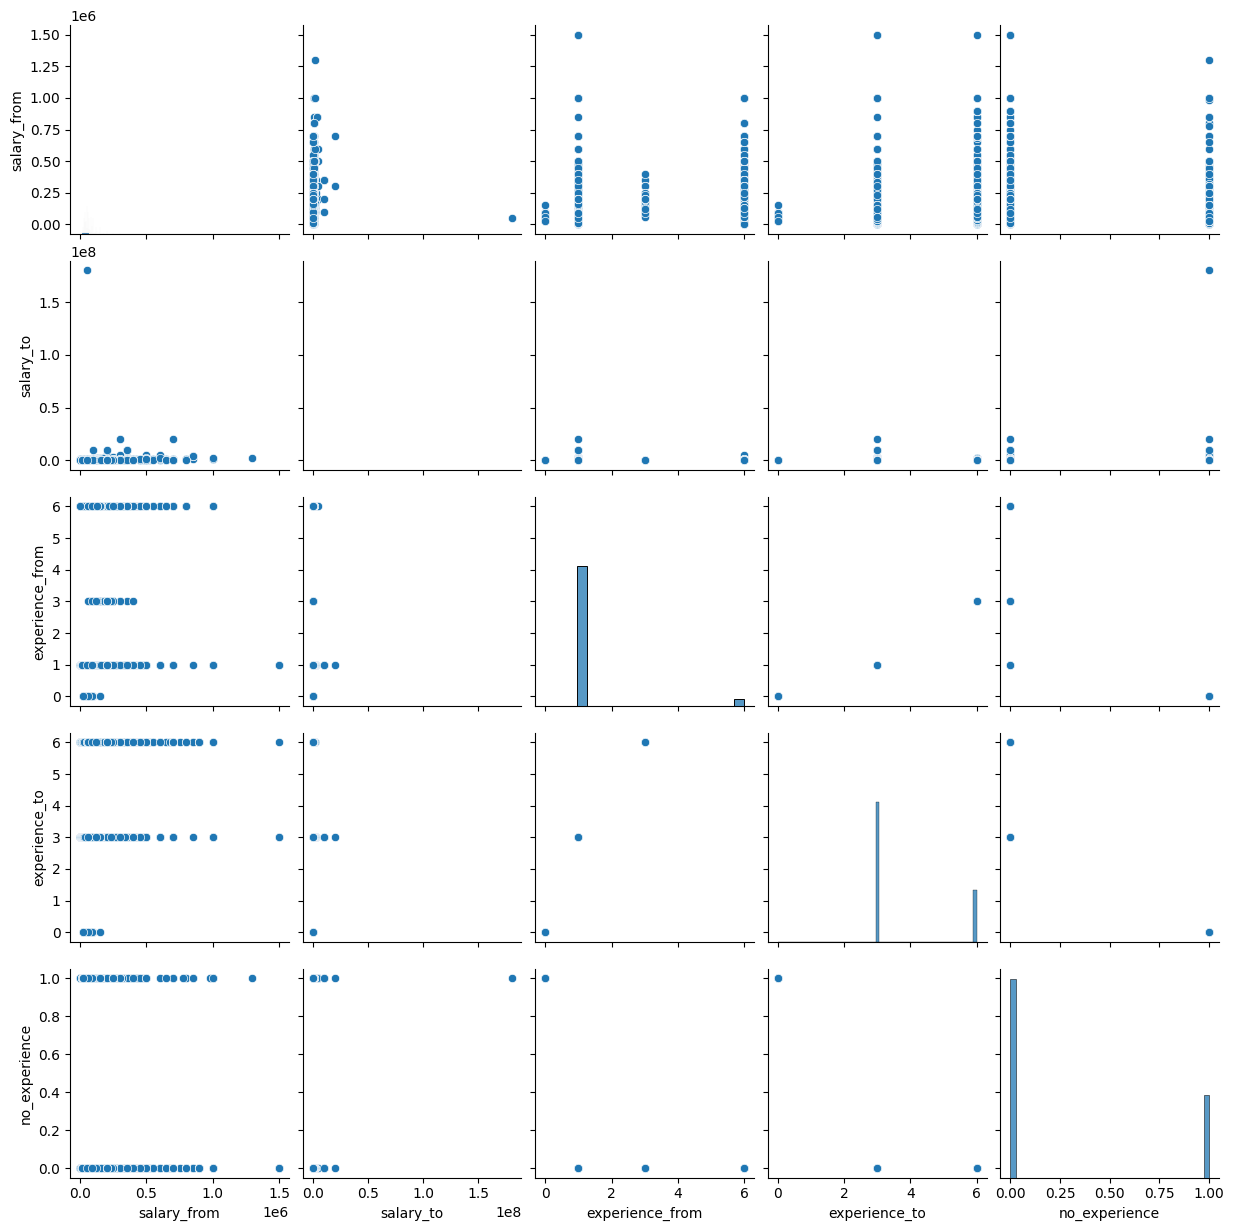

In [227]:
selected_columns = ['salary_from', 'salary_to', 'experience_from', 'experience_to', 'no_experience']
sns.pairplot(data_set_123_clean_salary[selected_columns])
plt.show()

Из приведенного выше графика можно сделать вывод, что нижний порог зарплаты прямо скоррелирован с верхним порогом зарплаты.
У тех, у кого опыт работы насчитывает более 6 лет, бывает более высокая зарплата, чем у тех, у кого опыт работы соствляет более одного года. Однако, наблюдений о более промежуточных вариантах нет. Кроме того, в вакансиях, требующих опыта работы от 6 лет, в основном предлагается такая же зарплата, как в вакансиях, требующих опыта от 1 года.
С максимальным допустимым опытом работы аналогичная связь: в вакансиях, требующих до 6 лет опыта работы, встречаются обещания более высокой зарпалвты, чем в вакансиях, предполагающих не более года опыта работы.
Ожидаемым образом, в вакансиях, не требующих опыта работы, обещания о размере заработной платы, как правило, меньше, чем в вакансиях с требованиями об опыте работы.

Заполним пропуски в столбце city по значениею в столбце company -- будем записывать в столбец city самый частотный город для этой компании.

In [228]:
def fill_na_by_most_frequent_per_group(df, column_x, column_y):
    """
    Заполняет пропуски в столбце X самой частотной категорией из X для каждого значения Y
    
    Parameters:
    df - DataFrame
    column_x - столбец с пропусками для заполнения
    column_y - столбец для группировки
    """
    df_copy = df.copy()
    
    # Считаем самые частотные значения
    mode_per_group = df_copy.groupby(column_y)[column_x].apply(
        lambda x: x.mode().iloc[0] if not x.mode().empty else 'nan'
    ).to_dict()
    
    
    # Правильное определение строковых 'nan'
    mask_na = df_copy[column_x] == 'nan'
    
    
    # Заполняем пропуски
    df_copy.loc[mask_na, column_x] = df_copy.loc[mask_na, column_y].map(mode_per_group)

    
    return df_copy

In [229]:
def fill_na_by_most_frequent_per_group(df, column_x, column_y):
    """
    Заполняет пропуски в столбце X самой частотной категорией из X для каждого значения Y
    Обрабатывает все типы пропусков: настоящие NaN, строки 'nan', пустые строки
    """
    df_copy = df.copy()
    
    print(f"=== ДИАГНОСТИКА ДЛЯ {column_x} ===")
    
    # Определяем ВСЕ типы пропусков
    mask_real_na = df_copy[column_x].isna()
    mask_string_nan = df_copy[column_x] == 'nan'
    mask_empty = df_copy[column_x] == ''
    
    total_na = mask_real_na.sum() + mask_string_nan.sum() + mask_empty.sum()
    print(f"Настоящие NaN: {mask_real_na.sum()}")
    print(f"Строки 'nan': {mask_string_nan.sum()}")
    print(f"Пустые строки: {mask_empty.sum()}")
    print(f"Всего пропусков: {total_na}")
    
    # Создаем временный столбец, где все пропуски заменяем на метку
    temp_x = df_copy[column_x].copy()
    temp_x = temp_x.fillna('_TEMP_NAN_')  # заменяем настоящие NaN
    temp_x = temp_x.replace('nan', '_TEMP_NAN_')  # заменяем строки 'nan'
    temp_x = temp_x.replace('', '_TEMP_NAN_')  # заменяем пустые строки
    
    # Считаем самые частотные значения, игнорируя временные метки
    mode_per_group = df_copy[temp_x != '_TEMP_NAN_'].groupby(column_y)[column_x].apply(
        lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown'
    ).to_dict()
    
    print(f"\nСамые частотные категории для каждой группы:")
    for y_value, x_mode in list(mode_per_group.items())[:10]:  # покажем первые 10
        print(f"  {column_y}={y_value} -> {column_x}={x_mode}")
    
    # Заполняем ВСЕ типы пропусков
    # 1. Настоящие NaN
    df_copy.loc[mask_real_na, column_x] = df_copy.loc[mask_real_na, column_y].map(mode_per_group)
    
    # 2. Строки 'nan'
    df_copy.loc[mask_string_nan, column_x] = df_copy.loc[mask_string_nan, column_y].map(mode_per_group)
    
    # 3. Пустые строки
    df_copy.loc[mask_empty, column_x] = df_copy.loc[mask_empty, column_y].map(mode_per_group)
    
    # Проверяем результат
    remaining_na = df_copy[column_x].isna().sum()
    remaining_string_nan = (df_copy[column_x] == 'nan').sum()
    remaining_empty = (df_copy[column_x] == '').sum()
    
    print(f"\nПосле заполнения:")
    print(f"Осталось настоящих NaN: {remaining_na}")
    print(f"Осталось строк 'nan': {remaining_string_nan}")
    print(f"Осталось пустых строк: {remaining_empty}")
    
    return df_copy

In [230]:
data_set_123_clean_salary_nona = fill_na_by_most_frequent_per_group(data_set_123_clean_salary, 'city', 'company')

=== ДИАГНОСТИКА ДЛЯ city ===
Настоящие NaN: 0
Строки 'nan': 118526
Пустые строки: 795
Всего пропусков: 119321

Самые частотные категории для каждой группы:
  company= DANTONE HOME -> city=казань
  company= L P H  -> city=санкт-петербур
  company= ЗАВОД КриалЭнергоСтрой -> city=казань
  company= Центр развития персонала Успех -> city=саранск
  company=#COLORSTAR STUDIO NAIL -> city=уфа
  company=#FARШ -> city=москва
  company=#IZUM -> city=москва
  company=#LAPOTOK -> city=дзержинск
  company=#БУСТОРАНЫ -> city=ярославль
  company=#ДАРИПОДАРКИ -> city=пермь

После заполнения:
Осталось настоящих NaN: 42064
Осталось строк 'nan': 0
Осталось пустых строк: 0


In [231]:
data_set_123_clean_salary_nona['city'].value_counts()

city
москва            63710
санкт-петербур    26366
екатеринбур       10103
краснодар          7200
новосибирск        6929
                  ...  
анашкино              1
коровяковка           1
самойловка            1
самусь                1
лохино                1
Name: count, Length: 2849, dtype: int64

Перекодируем категориальные переменные, так, чтобы самые частотные значения остались, а остальные -- слились в категорию other. При этом сохраняем такие категрии, у которых наиболее экстримальные значения salary_from -- экстремально высокие и экстремально низкие.

In [232]:
import pandas as pd
import numpy as np

def recode_categorical_by_frequency(df, column_name, salary_column='salary_from', threshold=0.001):
    """
    Перекодирует категориальную переменную по частотности с обработкой пропущенных значений
    Сохраняет категории, связанные с топ-10 и анти-топ-10 значениями salary_from
    """
    df_copy = df.copy()
    
    # Создаем временную копию столбца, где заменяем NaN на специальное значение
    temp_series = df_copy[column_name].copy()
    temp_series = temp_series.fillna('_MISSING_')
    
    # Считаем частотность каждой категории (включая пропущенные)
    value_counts = temp_series.value_counts(normalize=True)
    
    # Находим категории, которые составляют менее threshold
    rare_categories = value_counts[value_counts < threshold].index
    
    # Находим топ-10 и анти-топ-10 значений salary_from
    top_10_salary = df_copy[salary_column].nlargest(10)
    anti_top_10_salary = df_copy[salary_column].nsmallest(10)
    
    # Получаем индексы строк с экстремальными значениями salary
    extreme_salary_indices = set(top_10_salary.index) | set(anti_top_10_salary.index)
    
    # Получаем категории, которые нужно сохранить (из строк с экстремальными salary)
    categories_to_preserve = set()
    for idx in extreme_salary_indices:
        category_value = df_copy.loc[idx, column_name]
        if pd.notna(category_value) and category_value != 'nan':
            categories_to_preserve.add(category_value)
    
    
    # Заменяем редкие категории на 'other', но сохраняем категории из экстремальных salary
    def recode_value(x, idx):
        if pd.isna(x):
            return np.nan  # Оставляем пропущенные значения как NaN
        elif x in rare_categories and x not in categories_to_preserve:
            return 'other'
        else:
            return x
    
    # Применяем функцию с передачей индекса
    df_copy[column_name] = [recode_value(x, idx) for idx, x in enumerate(df_copy[column_name])]
    
    # Альтернативный способ с apply (менее эффективный, но проще)
    # df_copy[column_name] = df_copy.apply(lambda row: recode_value(row[column_name], row.name), axis=1)
    
    return df_copy

In [233]:
data_set_123_clean_salary_nona_recoded = recode_categorical_by_frequency(data_set_123_clean_salary_nona, 'company', 'salary_from', 0.001)

In [234]:
data_set_123_clean_salary_nona_recoded['company'].value_counts()

company
other                                                    310373
Пятёрочка                                                  2531
МАГНИТ, Розничная сеть                                     2179
СБЕР                                                       2006
Консалтинг Групп                                           1239
Ростелеком                                                  966
ГК ПАРТНЁР                                                  921
Департамент Ф53                                             773
Почта России                                                735
Ozon                                                        724
Совкомбанк                                                  722
ЭКСПРЕСС                                                    717
Яндекс Крауд                                                660
ANCOR                                                       653
Jobers                                                      649
JCat.ru                         

In [235]:
data_set_123_clean_salary_nona_recoded_fully = recode_categorical_by_frequency(data_set_123_clean_salary_nona_recoded, 'city', 'salary_from', 0.01)

In [236]:
data_set_123_clean_salary_nona_recoded_fully_2 = recode_categorical_by_frequency(data_set_123_clean_salary_nona_recoded_fully, 'title_key', 'salary_from', 0.001)

In [237]:
data_set_123_clean_salary_nona_recoded_fully_2['title_key'].value_counts()

title_key
other                    55652
менеджер                 26240
специалист               22971
инженер                  11962
оператор                 10708
                         ...  
грузчик-комплектовщик      351
методист                   345
электромеханик             335
йога-фитнес                  4
вакансия                     2
Name: count, Length: 149, dtype: int64

In [238]:
data_set_123_clean_salary_nona_recoded_fully_2.to_csv('data_set_123_clean_salary_nona_recoded_fully_161025.csv')

In [239]:
def convert_all_string_columns_to_lowercase(df):
    """
    Автоматически находит все строковые колонки и переводит их в нижний регистр
    """
    df_copy = df.copy()
    
    string_columns = df_copy.select_dtypes(include=['object', 'string']).columns
    
    print(f"Найдено строковых колонок: {list(string_columns)}")
    
    for col in string_columns:
        if df_copy[col].dtype == 'object':
            df_copy[col] = df_copy[col].apply(
                lambda x: x.lower() if pd.notna(x) and isinstance(x, str) else x
            )
        else:
            df_copy[col] = df_copy[col].str.lower()
    
    return df_copy

In [240]:
data_set_123_clean_salary_nona_recoded_fully_2_lower = convert_all_string_columns_to_lowercase(data_set_123_clean_salary_nona_recoded_fully_2)

Найдено строковых колонок: ['title', 'description', 'key_skills', 'company', 'location', 'date_of_post', 'type', 'currency', 'job_type_concrete', 'schedule', 'city', 'description_clean', 'title_key']


In [241]:
data_set_123_clean_salary_nona_recoded_fully_2_lower.to_csv('data_set_123_clean_salary_nona_recoded_fully_lower_161025.csv')

In [248]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_categorical_vertical(df, target_var, cat_vars, figsize=(18, 35)):
    """
    Строит гистограммы одна под другой, показывающие зависимость целевой переменной от категориальных переменных
    
    Parameters:
    df - DataFrame с данными
    target_var - название целевой переменной
    cat_vars - список названий категориальных переменных
    figsize - размер графика
    """
    
    n_vars = len(cat_vars)
    
    # Создаем фигуру с n_vars субплогами в один столбец
    fig, axes = plt.subplots(n_vars, 1, figsize=figsize)
    
    # Если только одна переменная, преобразуем axes в массив
    if n_vars == 1:
        axes = [axes]
    
    # Цветовая палитра
    colors = plt.cm.Set3(np.linspace(0, 1, n_vars))
    
    for i, cat_var in enumerate(cat_vars):
        # Группируем данные по категориальной переменной и считаем среднее целевой переменной
        grouped_data = df.groupby(cat_var)[target_var].mean().sort_values(ascending=False)
        
        # Строим гистограмму
        bars = axes[i].bar(grouped_data.index.astype(str), grouped_data.values, 
                          color=colors[i], alpha=0.7, edgecolor='black')
        
        # Добавляем значения на столбцы
        for bar in bars:
            height = bar.get_height()
            axes[i].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                       f'{height:.0f}', ha='center', va='bottom', fontsize=9)
        
        # Настройки графика
        axes[i].set_title(f'{target_var} по {cat_var}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel(cat_var, fontsize=12)
        axes[i].set_ylabel(f'Среднее {target_var}', fontsize=12)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(axis='y', alpha=0.3)
        
        # Добавляем сетку
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


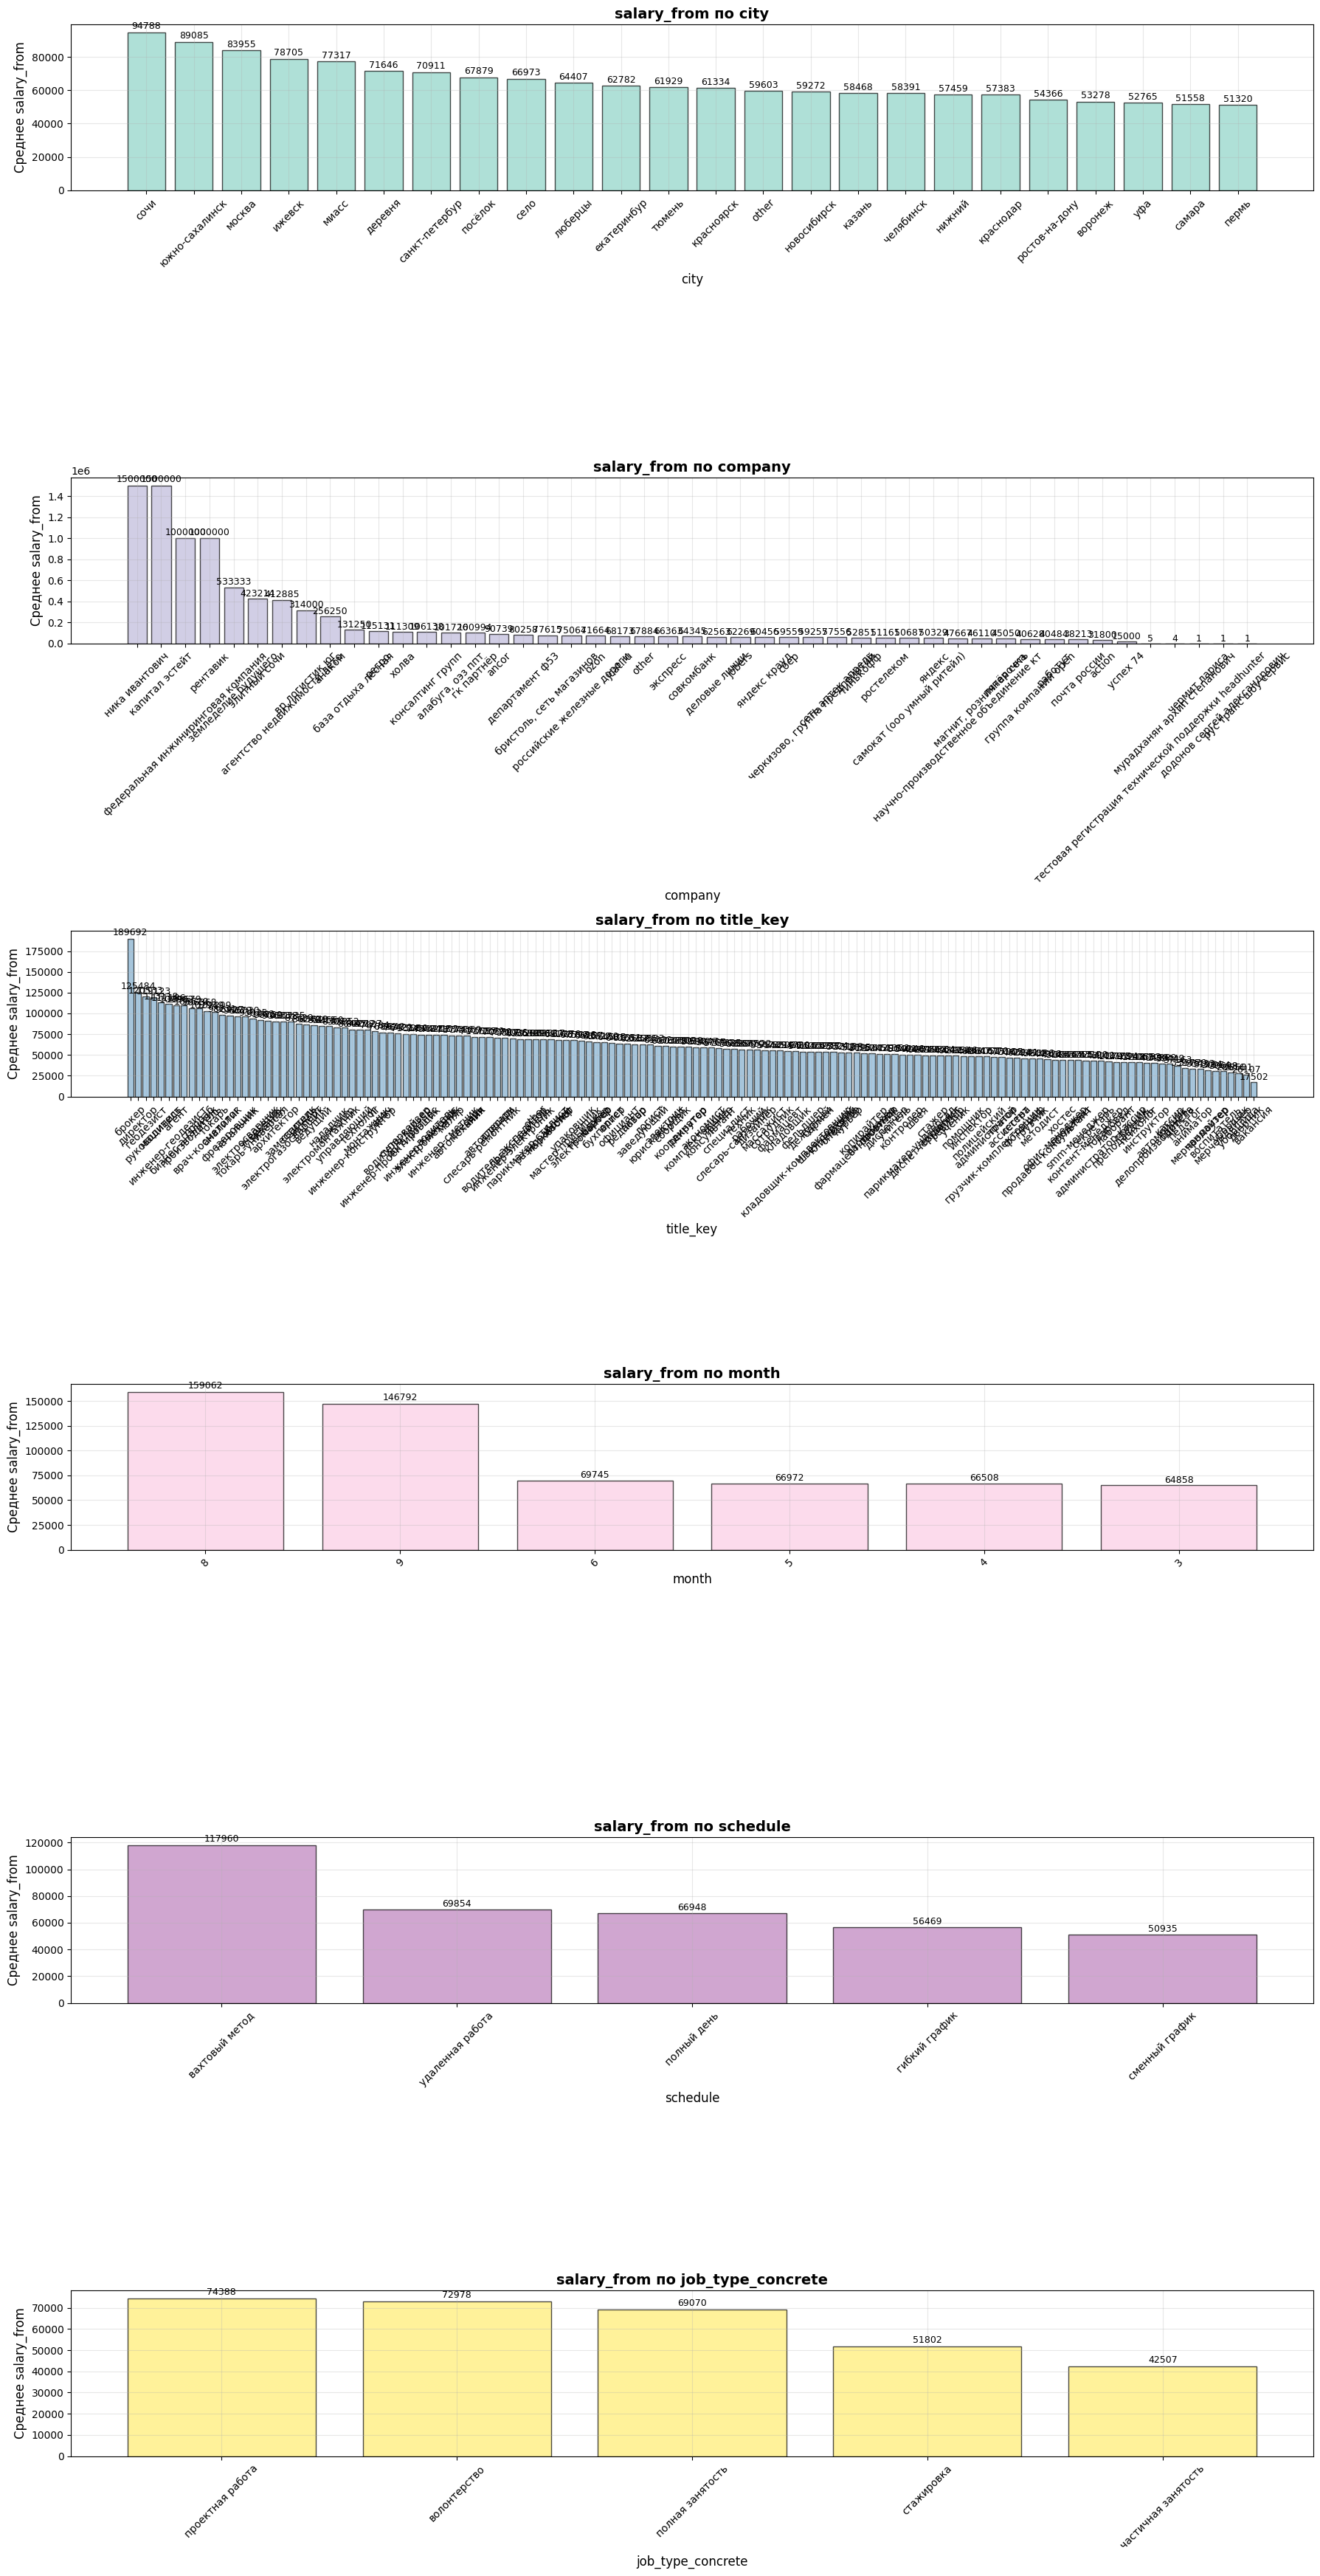

In [249]:
plot_categorical_vertical(data_set_123_clean_salary_nona_recoded_fully_2_lower, 'salary_from', ['city', 'company', 'title_key', 'month', 'schedule', 'job_type_concrete'])

По составленным гистограммам можно сделать следующие выводы: 

In [244]:
data = (data_set_123_clean_salary['salary_from']).astype(int)

In [245]:
print("=== АНАЛИЗ ДАННЫХ по столбцу salary_from ===")
print(f"Минимум: {data.min():,.0f}")
print(f"Максимум: {data.max():,.0f}")
print(f"Среднее: {data.mean():,.0f}")
print(f"Медиана: {data.median():,.0f}")
print(f"Стандартное отклонение: {data.std():,.0f}")

# Квартили
print(f"Q1 (25%): {data.quantile(0.25):,.0f}")
print(f"Q2 (50%): {data.quantile(0.50):,.0f}")
print(f"Q3 (75%): {data.quantile(0.75):,.0f}")
print(f"Q95 (95%): {data.quantile(0.95):,.0f}")

# Проверка на выбросы
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data < lower_bound) | (data > upper_bound)]
print(f"Выбросы: {len(outliers)} значений ({len(outliers)/len(data)*100:.1f}%)")

=== АНАЛИЗ ДАННЫХ по столбцу salary_from ===
Минимум: 1
Максимум: 1,500,000
Среднее: 67,739
Медиана: 55,000
Стандартное отклонение: 46,888
Q1 (25%): 40,000
Q2 (50%): 55,000
Q3 (75%): 80,000
Q95 (95%): 150,000
Выбросы: 21804 значений (6.6%)


In [246]:
data = data[~data.isin(outliers)]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


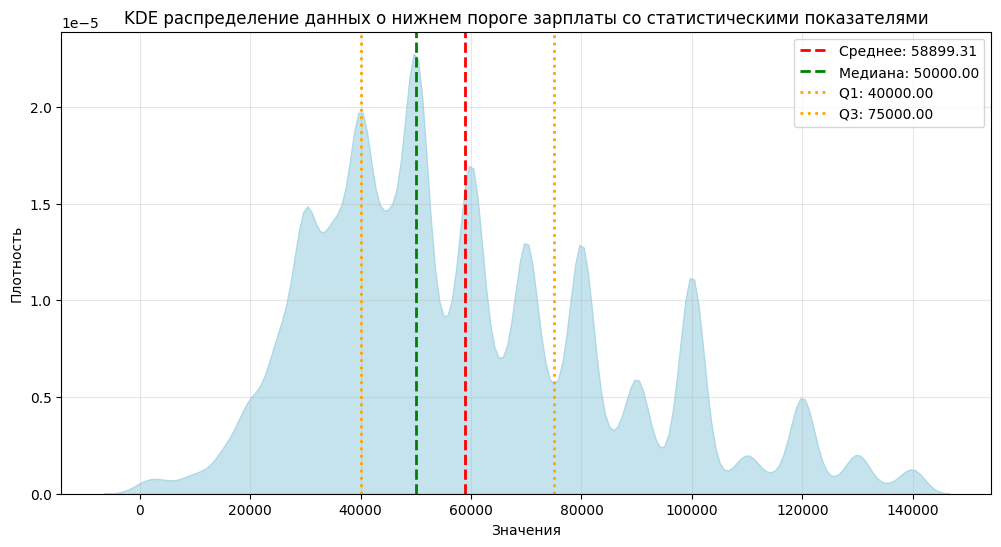

In [247]:
plt.figure(figsize=(12, 6))

# KDE plot вместо histplot
sns.kdeplot(data, fill=True, alpha=0.7, color='lightblue')

# Статистические показатели
stats = {
    'Среднее': data.mean(),
    'Медиана': data.median(),
    'Q1': data.quantile(0.25),
    'Q3': data.quantile(0.75)
}

colors = {'Среднее': 'red', 'Медиана': 'green', 'Q1': 'orange', 'Q3': 'orange'}
linestyles = {'Среднее': '--', 'Медиана': '--', 'Q1': ':', 'Q3': ':'}

for name, value in stats.items():
    plt.axvline(value, color=colors[name], linestyle=linestyles[name], 
                linewidth=2, label=f'{name}: {value:.2f}')

plt.xlabel('Значения')
plt.ylabel('Плотность')
plt.title('KDE распределение данных о нижнем пороге зарплаты со статистическими показателями')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## One-hot encoding

Закодируем с помощью one-hot encoding все категориальальные переменные.

In [253]:
from sklearn.preprocessing import OneHotEncoder

def one_hot_encode_sklearn(df, columns, drop_original=True, sparse=False):
    """
    One-hot кодирование с помощью sklearn OneHotEncoder
    
    Parameters:
    df - DataFrame
    columns - список колонок для кодирования
    drop_original - удалять ли оригинальные колонки
    sparse - возвращать разреженную матрицу (экономит память)
    """
    df_copy = df.copy()
    
    if isinstance(columns, str):
        columns = [columns]
    
    encoder = OneHotEncoder(sparse_output=sparse, drop='first')  # drop='first' чтобы избежать мультиколлинеарности
    
    # Применяем к указанным колонкам
    encoded_array = encoder.fit_transform(df_copy[columns])
    
    # Создаем имена для новых колонок
    feature_names = []
    for i, col in enumerate(columns):
        for category in encoder.categories_[i][1:]:  # пропускаем первую категорию если drop='first'
            feature_names.append(f"{col}_{category}")
    
    # Создаем DataFrame с закодированными признаками
    encoded_df = pd.DataFrame(encoded_array, columns=feature_names, index=df_copy.index)
    
    # Удаляем оригинальные колонки если нужно
    if drop_original:
        df_copy = df_copy.drop(columns, axis=1)
    
    # Объединяем с исходным DataFrame
    df_encoded = pd.concat([df_copy, encoded_df], axis=1)
    
    return df_encoded, encoder

In [252]:
data_set_123_clean_salary_nona_recoded_fully_2_lower.columns

Index(['№', 'id', 'title', 'description', 'key_skills', 'company', 'location',
       'date_of_post', 'type', 'salary_from', 'salary_to', 'currency',
       'experience_from', 'experience_to', 'no_experience',
       'job_type_concrete', 'schedule', 'city', 'description_clean',
       'title_key', 'salary_from_company_coefficient',
       'salary_to_company_coefficient', 'salary_from_title_coefficient',
       'salary_to_title_coefficient', 'salary_from_filled', 'month'],
      dtype='object')

In [254]:
df_one_hot_encoded, encoder = one_hot_encode_sklearn(data_set_123_clean_salary_nona_recoded_fully_2_lower, ['city', 'company', 'job_type_concrete', 'schedule', 'title_key', 'month'])

In [255]:
df_one_hot_encoded

,№,id,title,description,key_skills,location,date_of_post,type,salary_from,salary_to,...,title_key_электромонтер,title_key_электросварщик,title_key_энергетик,title_key_юрисконсульт,title_key_юрист,month_4,month_5,month_6,month_8,month_9
0,1.0,78577559,главный механик,"вакансия компании: ооо пк предприятие ""пик"" ...",NaN,владивосток,27.03.2023,close,160000.0,160000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,6.0,78465777,слесарь кипиа,"торгово-производственная компания зао ""росма...",NaN,"санкт-петербург, 3-я конная лахта, 48к4",23.04.2023,close,62000.0,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,7.0,78652831,начальник участка,в гк миланстрой требуется начальник участка!...,"autocad,ms excel,ms word,управление производст...","москва, улица ивана бабушкина, 4",29.03.2023,close,130000.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,8.0,69339467,ведущий архитектор,гк «олимпроект» - лидирующая компания в сф...,"autocad,autodesk revit,работа в команде,adobe ...","владивосток, океанский проспект, 17",13.04.2023,close,80000.0,100000.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8,9.0,78146411,директор по персоналу (hrd),компания «ортоника» является одним из веду...,"okr,kpi,грейдинг,онбординг,компетентностный по...","владимир, октябрьский проспект, 22",22.04.2023,close,250000.0,350000.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562927,NaN,86606262,руководитель digital - маркетинга / chief digi...,{'requirement': 'подтвержденные навыки построе...,NaN,москва,24.09.2023,open,200000.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
562945,NaN,83238366,senior java developer (в банк),"{'requirement': 'опыт работы с spring boot, sp...",NaN,москва,05.09.2023,open,350000.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
562952,NaN,79416232,аналитик dwh,{'requirement': 'опыт работы на проектах по вн...,NaN,москва,25.09.2023,open,200000.0,300000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
562972,NaN,82743325,лингвист-аналитик (со знанием арабского языка),{'requirement': 'высшее профильное образование...,NaN,москва,24.09.2023,open,90000.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
df_one_hot_encoded.to_csv('df_one_hot_encoded.csv')